# A. Setup + Load


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display
import numpy as np
from pandas.api.types import CategoricalDtype


pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 20)


In [2]:
COMPETITION = "cpe-232-insurance-premium-prediction"
NOTEBOOK_SLUG = "ins232-eda"


def resolve_local_data_dir() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / "data",
        cwd,
        cwd.parent / "data",
        cwd.parent,
    ]

    for directory in candidates:
        if (directory / "train.csv").exists() and (directory / "test.csv").exists():
            return directory

    raise FileNotFoundError("Could not find local train.csv and test.csv")


DATA_DIR = resolve_local_data_dir()
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
SAMPLE_PATH = DATA_DIR / "sample_submission.csv"

print("COMPETITION:", COMPETITION)
print("NOTEBOOK_SLUG:", NOTEBOOK_SLUG)
print("DATA_DIR:", DATA_DIR)


COMPETITION: cpe-232-insurance-premium-prediction
NOTEBOOK_SLUG: ins232-eda
DATA_DIR: /Users/beam/Workspace/Project/my-kaggle-notebooks/notebooks/2026-03-13-insurance-premium-prediction/data


In [3]:
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
sample_submission_df = pd.read_csv(SAMPLE_PATH)

print("train shape:", train_df.shape)
print("test shape:", test_df.shape)
print("sample_submission shape:", sample_submission_df.shape)


train shape: (520000, 20)
test shape: (80000, 19)
sample_submission shape: (80000, 2)


In [4]:
# Shared schema constants (used across all phases)
ID_COL = "id"
TARGET_COL = "Premium Amount"

NUM_COLS = [
    "Age",
    "Annual Income",
    "Number of Dependents",
    "Health Score",
    "Previous Claims",
    "Vehicle Age",
    "Credit Score",
    "Insurance Duration",
]

CAT_COLS = [
    "Gender",
    "Marital Status",
    "Education Level",
    "Occupation",
    "Location",
    "Policy Type",
    "Customer Feedback",
    "Smoking Status",
    "Exercise Frequency",
    "Property Type",
]

LOG_COLS = ["Annual Income", "Health Score", "Credit Score"]
WINSOR_COLS = NUM_COLS.copy()

train_expected = set([ID_COL, TARGET_COL] + NUM_COLS + CAT_COLS)
test_expected = set([ID_COL] + NUM_COLS + CAT_COLS)

missing_train_cols = sorted(train_expected - set(train_df.columns))
missing_test_cols = sorted(test_expected - set(test_df.columns))

assert not missing_train_cols, f"Missing train columns: {missing_train_cols}"
assert not missing_test_cols, f"Missing test columns: {missing_test_cols}"

print("Shared schema constants ready.")


Shared schema constants ready.


# A. Raw Tabular EDA


In [5]:
display(train_df.head())
display(test_df.head())
display(sample_submission_df.head())


,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
0,1,52.0,NaN,NaN,Married,1.0,NaN,NaN,46.39,Suburban,Comprehensive,1.0,19.0,770.12,NaN,Good,Yes,Monthly,House,458.84
1,2,54.0,Male,20482.06,NaN,NaN,Master's,NaN,27.70,Suburban,NaN,1.0,NaN,704.13,5.0,Average,Yes,Weekly,Condo,200.05
2,3,27.0,Female,17775.08,Divorced,0.0,NaN,Self-Employed,29.28,Urban,Premium,0.0,12.0,NaN,1.0,Average,Yes,Weekly,NaN,223.93
3,4,47.0,Female,58531.02,Married,0.0,Bachelor's,Self-Employed,44.32,Urban,NaN,0.0,12.0,419.07,5.0,Good,No,Daily,NaN,278.17
4,5,38.0,Female,86930.27,Single,1.0,Master's,Self-Employed,68.03,Rural,Basic,1.0,14.0,650.90,9.0,Good,NaN,Daily,House,306.93


,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Customer Feedback,Smoking Status,Exercise Frequency,Property Type
0,520001,53.0,Male,35635.49,Married,0.0,PhD,Self-Employed,42.76,Suburban,Premium,NaN,0.0,724.56,7.0,Good,Yes,Weekly,House
1,520002,63.0,Male,134117.55,NaN,3.0,High School,NaN,43.93,Urban,NaN,1.0,18.0,445.92,5.0,Average,No,Weekly,Apartment
2,520003,46.0,Male,111860.17,NaN,2.0,High School,Employed,27.53,Suburban,NaN,0.0,4.0,NaN,9.0,Average,Yes,Daily,NaN
3,520004,57.0,Female,3821.12,Married,1.0,Master's,Employed,24.59,Rural,Comprehensive,1.0,NaN,333.00,3.0,Average,Yes,Daily,NaN
4,520005,60.0,Female,NaN,Single,4.0,NaN,Unemployed,38.77,NaN,Comprehensive,1.0,19.0,811.33,3.0,Good,Yes,Monthly,Apartment


,id,Premium Amount
0,520001,0.0
1,520002,0.0
2,520003,0.0
3,520004,NaN
4,520005,NaN


In [6]:
summary_df = pd.DataFrame(
    {
        "dtype": train_df.dtypes.astype(str),
        "missing": train_df.isna().sum(),
        "missing_pct": (train_df.isna().mean() * 100).round(2),
        "nunique": train_df.nunique(dropna=False),
    }
).sort_values(["missing", "nunique"], ascending=[False, False])

display(summary_df)


,dtype,missing,missing_pct,nunique
Occupation,str,207585,39.92,4
Annual Income,float64,153030,29.43,353473
Marital Status,str,133853,25.74,4
Location,str,123333,23.72,4
Smoking Status,str,100176,19.26,3
Health Score,float64,92173,17.73,7739
Customer Feedback,str,89054,17.13,4
Education Level,str,83933,16.14,5
Credit Score,float64,83624,16.08,55141
Property Type,str,80150,15.41,4


In [7]:
display(train_df.describe(include="all").transpose())


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,520000.0,NaN,NaN,NaN,260000.5,150111.214327,1.0,130000.75,260000.5,390000.25,520000.0
Age,460257.0,NaN,NaN,NaN,48.259166,11.763984,17.0,39.0,52.0,57.0,66.0
Gender,489711,2,Male,275069,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Annual Income,366970.0,NaN,NaN,NaN,40851.926105,35960.673567,0.0,14525.7325,29855.435,61401.3575,154551.33
Marital Status,386147,3,Divorced,184639,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Number of Dependents,458033.0,NaN,NaN,NaN,1.72359,1.462789,0.0,0.0,1.0,3.0,4.0
Education Level,436067,4,High School,136237,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Occupation,312415,3,Employed,129570,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Health Score,427827.0,NaN,NaN,NaN,28.854542,14.027797,0.0,16.72,26.61,40.33,88.14
Location,396667,3,Suburban,162153,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# A. Raw Visual EDA


In [8]:
# Output directory management (clear outputs on each run)
from pathlib import Path
import shutil

OUTPUT_DIR = Path.cwd() / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

deleted_items = 0
for item in OUTPUT_DIR.iterdir():
    if item.is_file() or item.is_symlink():
        item.unlink()
        deleted_items += 1
    elif item.is_dir():
        shutil.rmtree(item)
        deleted_items += 1

print(f"OUTPUT_DIR ready: {OUTPUT_DIR}")
print(f"Cleared items: {deleted_items}")


OUTPUT_DIR ready: /Users/beam/Workspace/Project/my-kaggle-notebooks/notebooks/2026-03-13-insurance-premium-prediction/outputs
Cleared items: 34


In [9]:
# Phase A guardrail: raw data + shared schema must be loaded
required_phase_a = ["train_df", "test_df", "NUM_COLS", "TARGET_COL"]
missing_phase_a = [name for name in required_phase_a if name not in globals()]
assert not missing_phase_a, f"Run A. Setup + Load first. Missing: {missing_phase_a}"
print("Phase A guardrail passed.")


Phase A guardrail passed.


In [10]:
# === INS232 visual EDA issue scan ===
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

EDA_RANDOM_SEED = 232
SAMPLE_SCATTER_N = 50_000
SAMPLE_HEATMAP_N = 80_000


def save_plot(fig, name: str) -> Path:
    path = OUTPUT_DIR / f"{NOTEBOOK_SLUG}_{name}.png"
    fig.savefig(path, bbox_inches="tight", dpi=150)
    return path


def save_df(df: pd.DataFrame, name: str) -> Path:
    path = OUTPUT_DIR / f"{name}_{NOTEBOOK_SLUG}.csv"
    df.to_csv(path, index=False)
    return path


print("Visual EDA setup complete.")
print(f"Artifacts will be saved to: {OUTPUT_DIR}")


Visual EDA setup complete.
Artifacts will be saved to: /Users/beam/Workspace/Project/my-kaggle-notebooks/notebooks/2026-03-13-insurance-premium-prediction/outputs


In [11]:
# Build EDA source frames (raw-first diagnostics)
eda_raw_train_df = train_df.copy(deep=True)
eda_raw_test_df = test_df.copy(deep=True)

eda_raw_train_sample = eda_raw_train_df.sample(
    n=min(SAMPLE_HEATMAP_N, len(eda_raw_train_df)),
    random_state=EDA_RANDOM_SEED,
)

print("Raw EDA source frames prepared.")


Raw EDA source frames prepared.


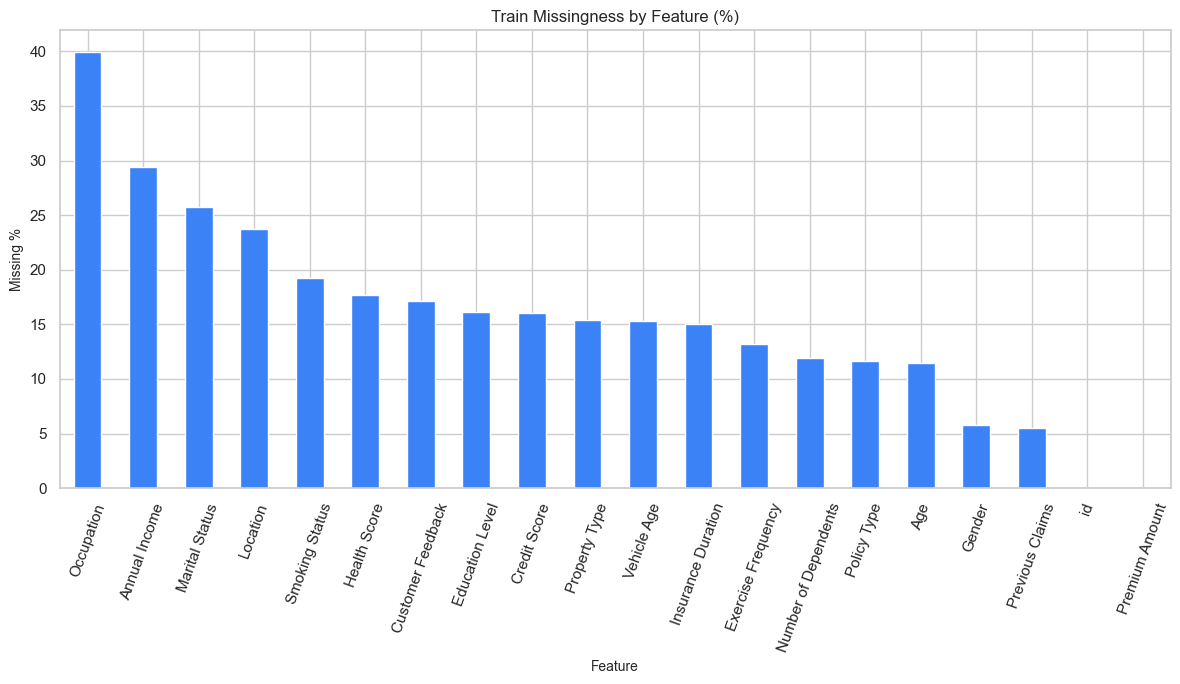

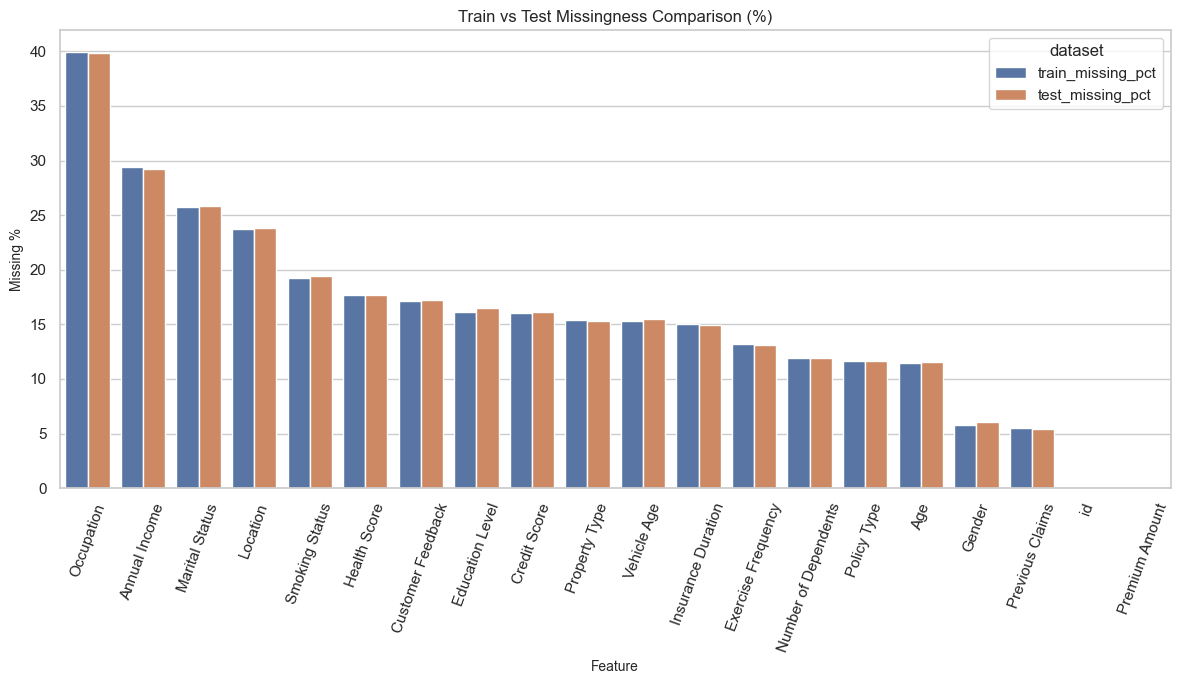

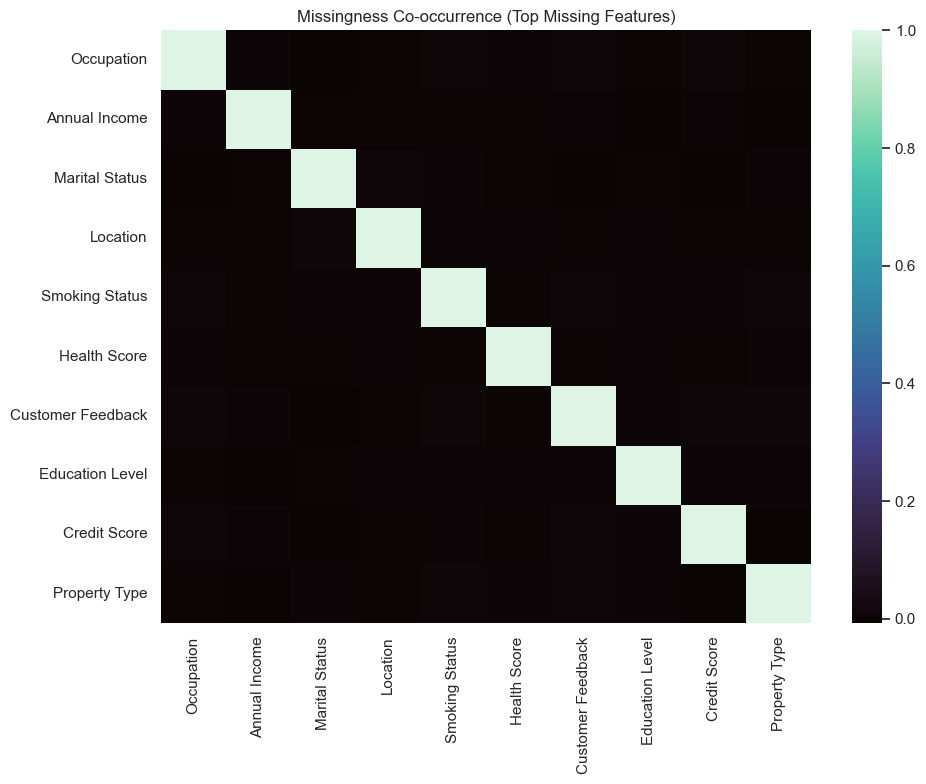

In [12]:
# Missingness overview and train/test missingness drift
train_missing_pct = eda_raw_train_df.isna().mean().mul(100).sort_values(ascending=False)
test_missing_pct = eda_raw_test_df.isna().mean().mul(100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
train_missing_pct.plot(kind="bar", ax=ax, color="#3b82f6")
ax.set_title("Train Missingness by Feature (%)")
ax.set_ylabel("Missing %")
ax.set_xlabel("Feature")
plt.xticks(rotation=70)
plt.tight_layout()
save_plot(fig, "missingness_train_pct")
plt.show()

missing_compare_df = pd.DataFrame(
    {
        "train_missing_pct": train_missing_pct,
        "test_missing_pct": test_missing_pct.reindex(train_missing_pct.index).fillna(0),
    }
).reset_index(names="feature")
missing_compare_long_df = missing_compare_df.melt(
    id_vars="feature",
    value_vars=["train_missing_pct", "test_missing_pct"],
    var_name="dataset",
    value_name="missing_pct",
)

fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(
    data=missing_compare_long_df, x="feature", y="missing_pct", hue="dataset", ax=ax
)
ax.set_title("Train vs Test Missingness Comparison (%)")
ax.set_ylabel("Missing %")
ax.set_xlabel("Feature")
plt.xticks(rotation=70)
plt.tight_layout()
save_plot(fig, "missingness_train_vs_test")
plt.show()

top_missing_cols = train_missing_pct.head(10).index.tolist()
missing_matrix = eda_raw_train_sample[top_missing_cols].isna().astype(int).corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(missing_matrix, cmap="mako", ax=ax)
ax.set_title("Missingness Co-occurrence (Top Missing Features)")
plt.tight_layout()
save_plot(fig, "missingness_cooccurrence_top10")
plt.show()


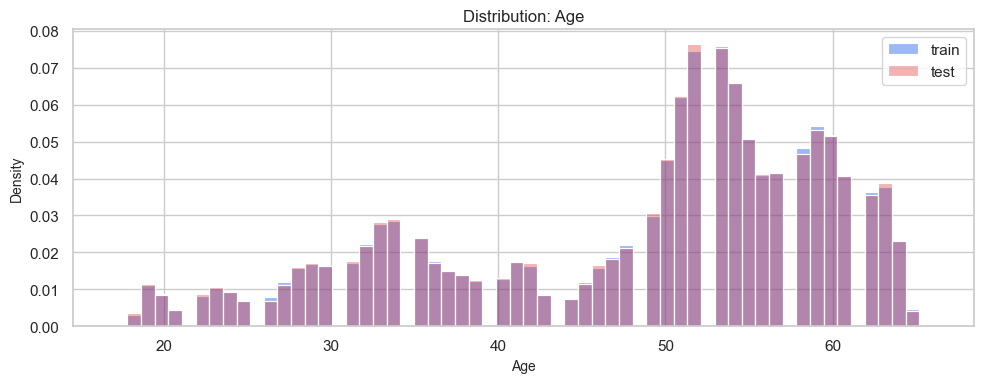

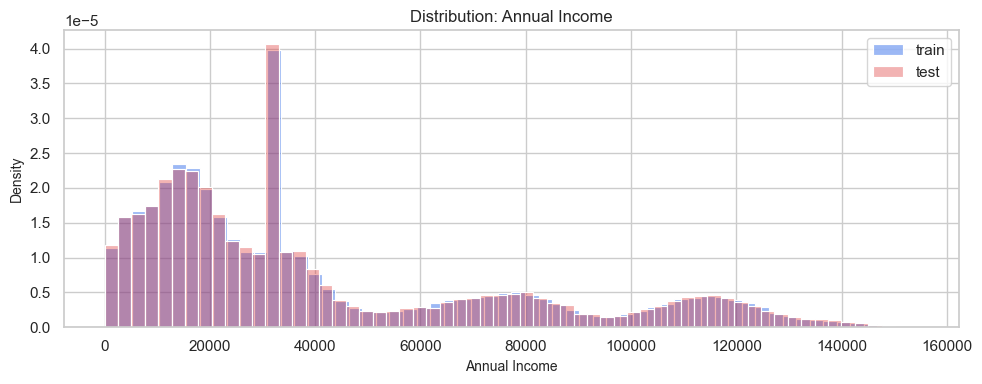

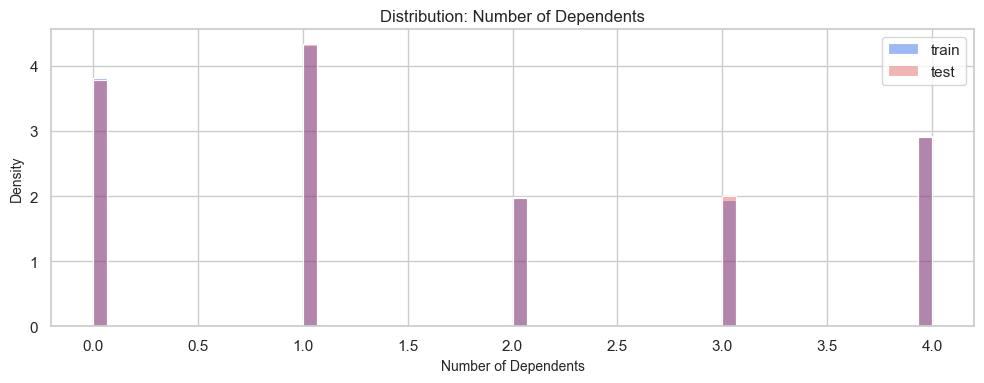

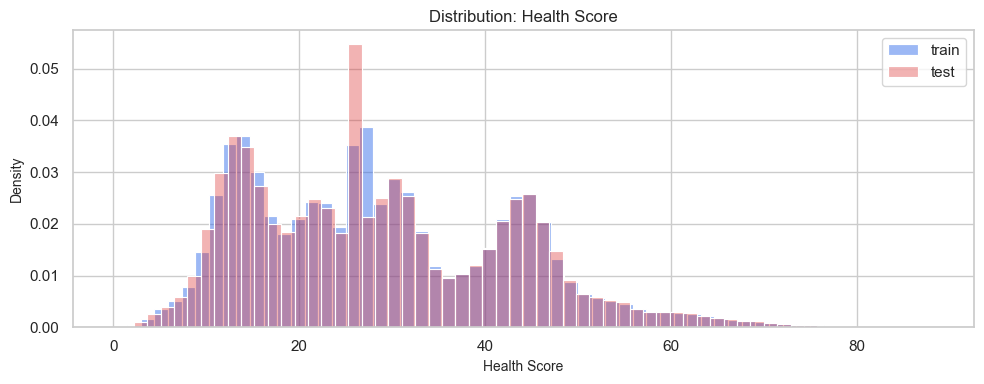

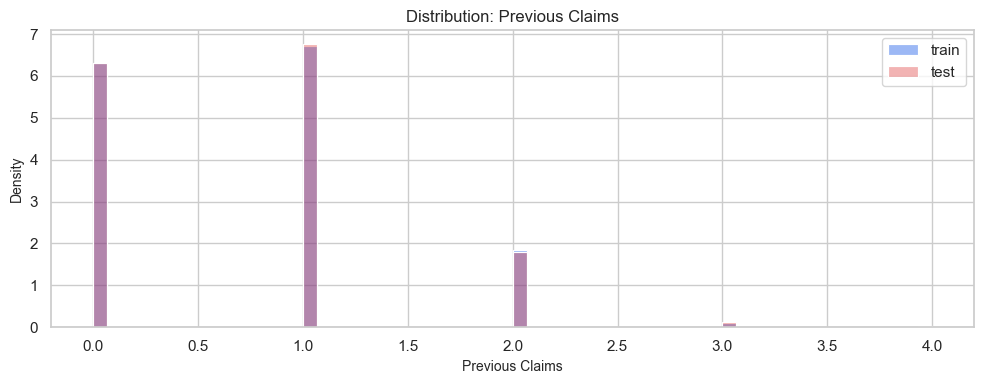

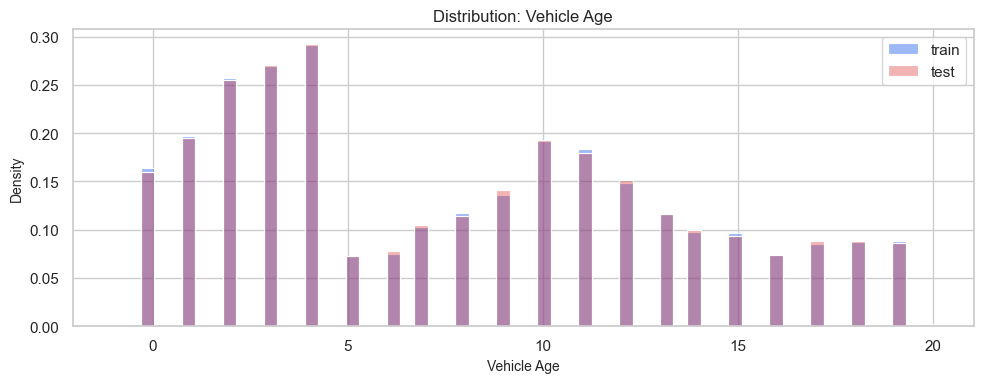

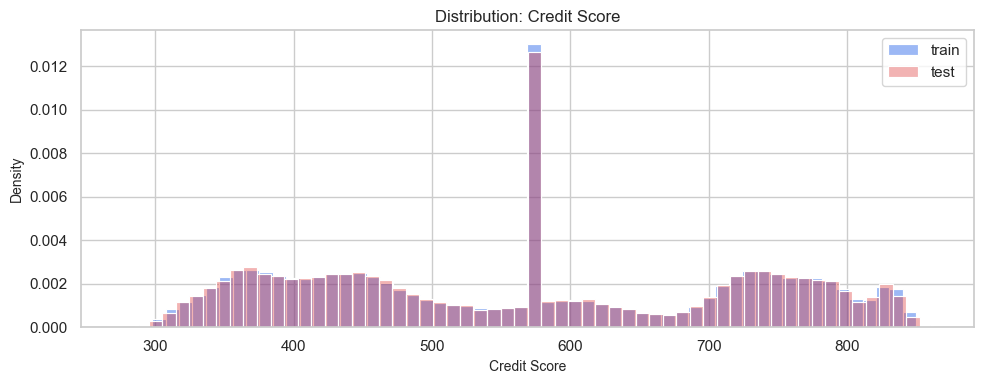

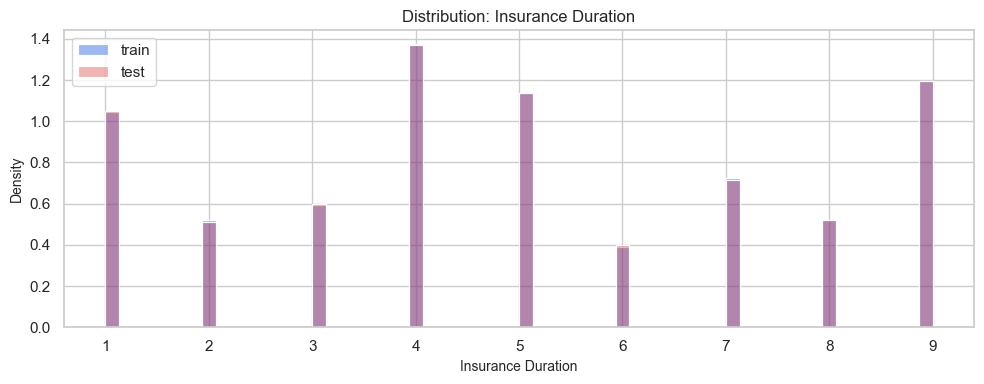

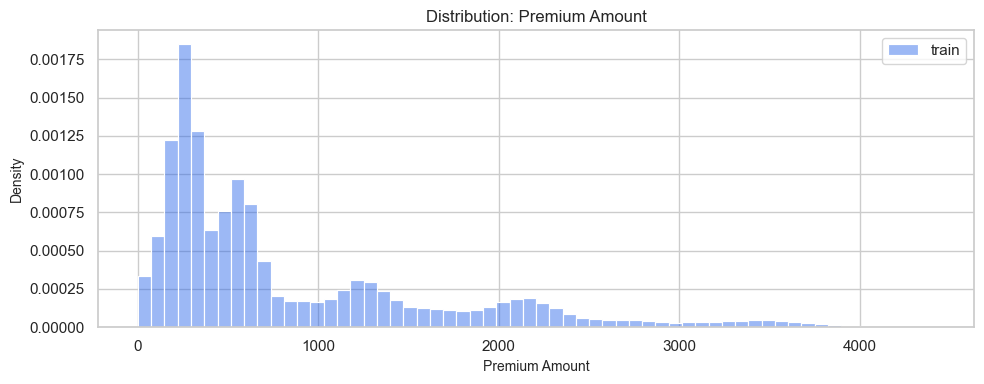

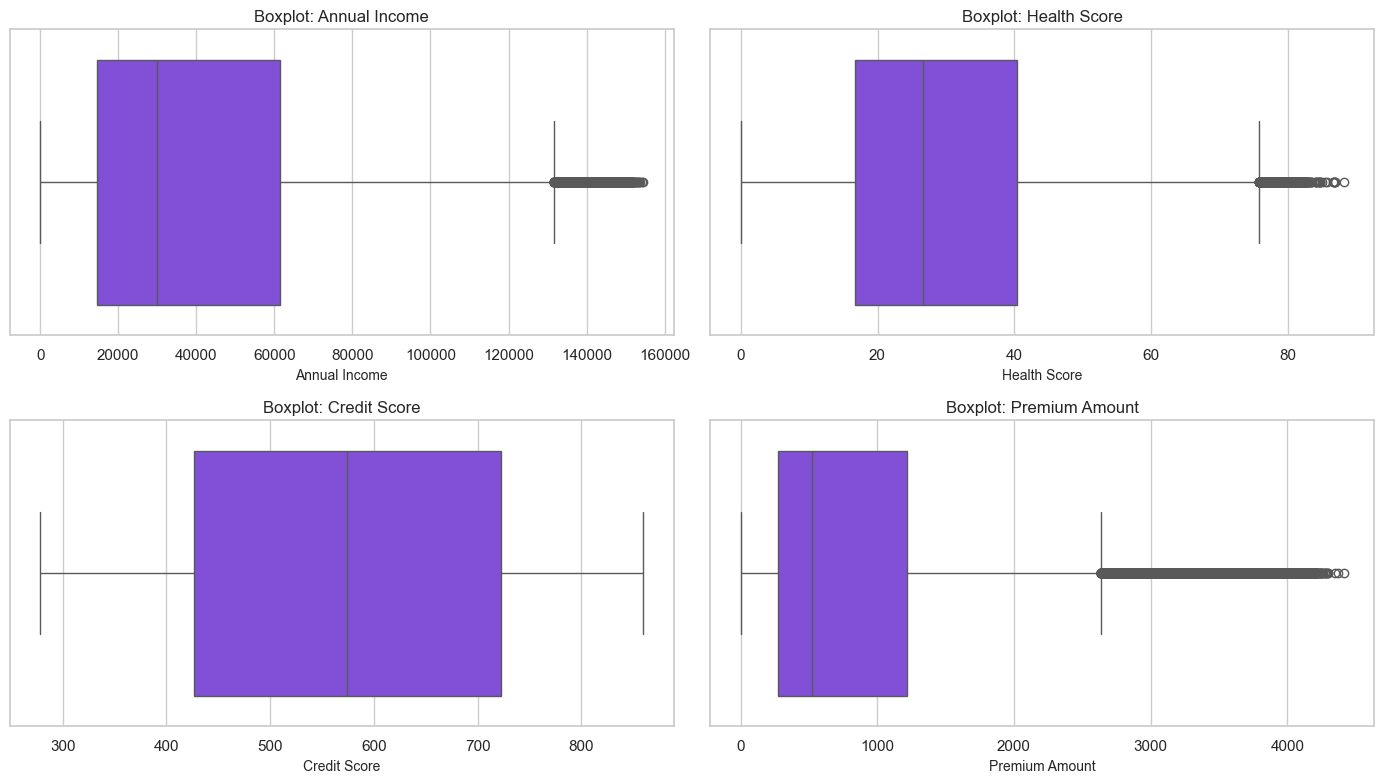

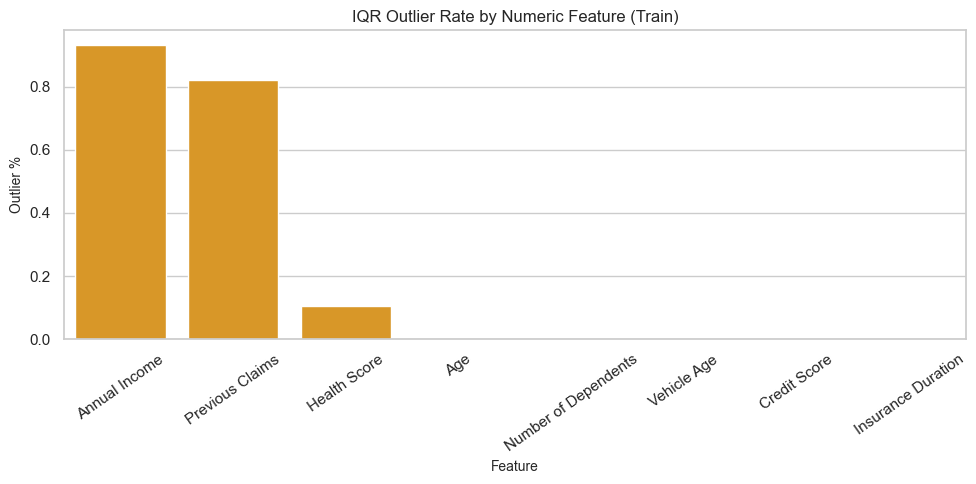

In [13]:
# Numeric distributions and outlier diagnostics
numeric_all_cols = NUM_COLS + [TARGET_COL]
plot_numeric_cols = [c for c in numeric_all_cols if c in eda_raw_train_df.columns]

# Histograms with train/test overlay where available
for col in plot_numeric_cols:
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.histplot(
        eda_raw_train_df[col],
        bins=60,
        stat="density",
        color="#2563eb",
        alpha=0.45,
        label="train",
        ax=ax,
    )
    if col in eda_raw_test_df.columns:
        sns.histplot(
            eda_raw_test_df[col],
            bins=60,
            stat="density",
            color="#dc2626",
            alpha=0.35,
            label="test",
            ax=ax,
        )
    ax.set_title(f"Distribution: {col}")
    ax.legend()
    plt.tight_layout()
    safe_col = col.lower().replace(" ", "_")
    save_plot(fig, f"numeric_dist_{safe_col}")
    plt.show()

skew_cols = [
    c
    for c in ["Annual Income", "Health Score", "Credit Score", TARGET_COL]
    if c in eda_raw_train_df.columns
]
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()
for idx, col in enumerate(skew_cols):
    sns.boxplot(x=eda_raw_train_df[col], ax=axes[idx], color="#7c3aed")
    axes[idx].set_title(f"Boxplot: {col}")
for idx in range(len(skew_cols), len(axes)):
    axes[idx].axis("off")
plt.tight_layout()
save_plot(fig, "boxplot_skew_features")
plt.show()

outlier_rows = []
for col in NUM_COLS:
    q1 = eda_raw_train_df[col].quantile(0.25)
    q3 = eda_raw_train_df[col].quantile(0.75)
    iqr = q3 - q1
    if pd.isna(iqr) or iqr == 0:
        outlier_rate = 0.0
    else:
        lb = q1 - 1.5 * iqr
        ub = q3 + 1.5 * iqr
        outlier_rate = float(
            ((eda_raw_train_df[col] < lb) | (eda_raw_train_df[col] > ub)).mean() * 100
        )
    outlier_rows.append({"feature": col, "iqr_outlier_pct": outlier_rate})

outlier_df = pd.DataFrame(outlier_rows).sort_values("iqr_outlier_pct", ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=outlier_df, x="feature", y="iqr_outlier_pct", ax=ax, color="#f59e0b")
ax.set_title("IQR Outlier Rate by Numeric Feature (Train)")
ax.set_ylabel("Outlier %")
ax.set_xlabel("Feature")
plt.xticks(rotation=35)
plt.tight_layout()
save_plot(fig, "iqr_outlier_rate")
plt.show()


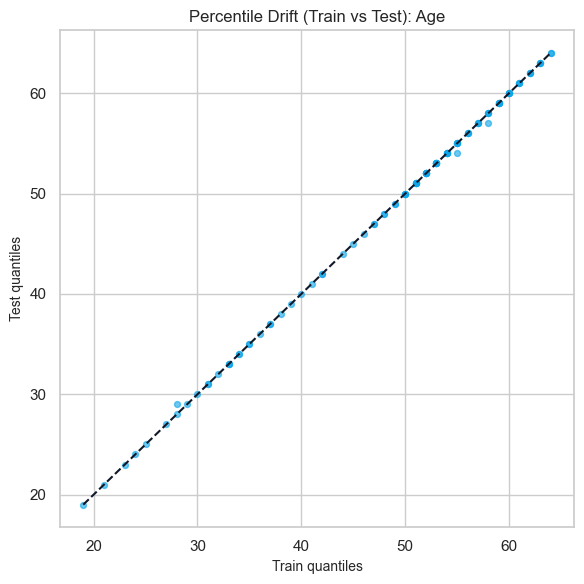

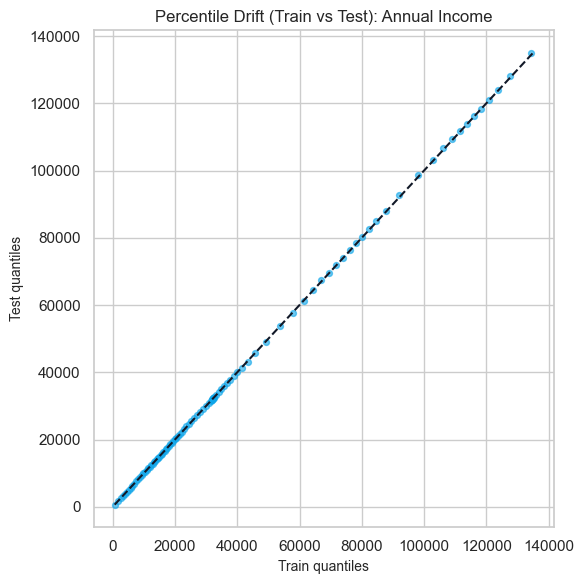

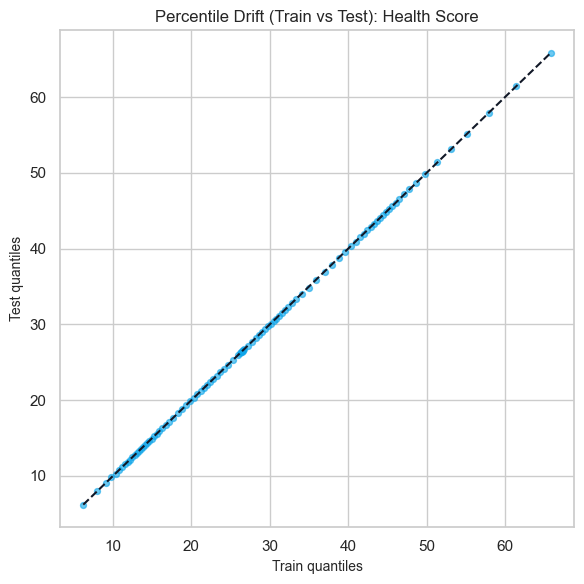

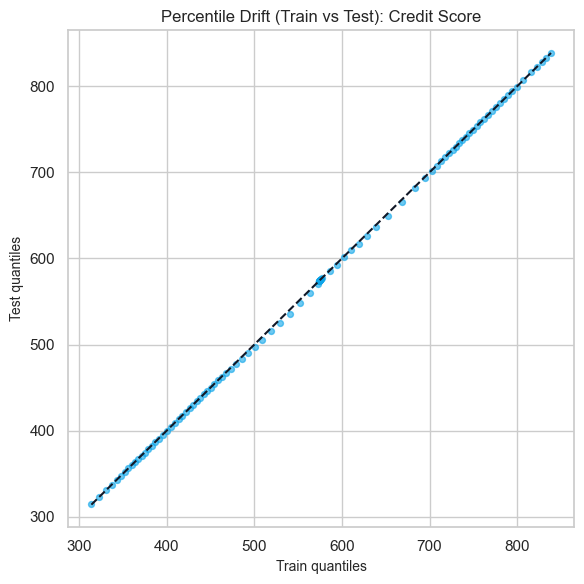

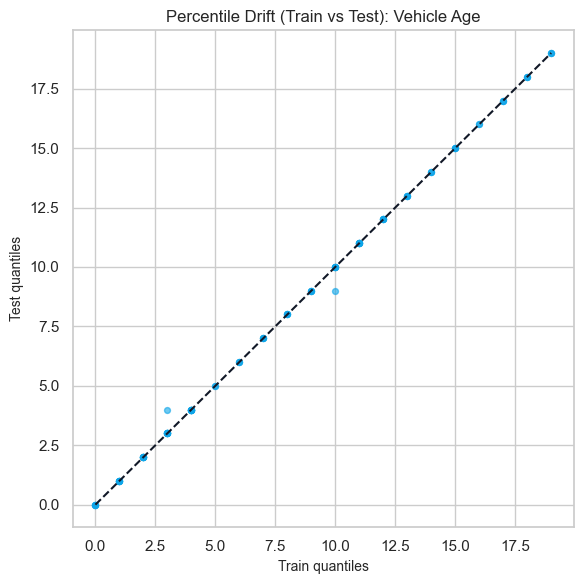

In [14]:
# Train vs test percentile drift (QQ-style diagnostics)
percentiles = np.linspace(0.01, 0.99, 99)
qq_cols = [
    c
    for c in ["Age", "Annual Income", "Health Score", "Credit Score", "Vehicle Age"]
    if c in eda_raw_test_df.columns
]

for col in qq_cols:
    train_q = eda_raw_train_df[col].quantile(percentiles)
    test_q = eda_raw_test_df[col].quantile(percentiles)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(train_q, test_q, s=18, alpha=0.6, color="#0ea5e9")
    min_v = np.nanmin([train_q.min(), test_q.min()])
    max_v = np.nanmax([train_q.max(), test_q.max()])
    ax.plot([min_v, max_v], [min_v, max_v], linestyle="--", color="#111827")
    ax.set_title(f"Percentile Drift (Train vs Test): {col}")
    ax.set_xlabel("Train quantiles")
    ax.set_ylabel("Test quantiles")
    plt.tight_layout()
    safe_col = col.lower().replace(" ", "_")
    save_plot(fig, f"qq_drift_{safe_col}")
    plt.show()


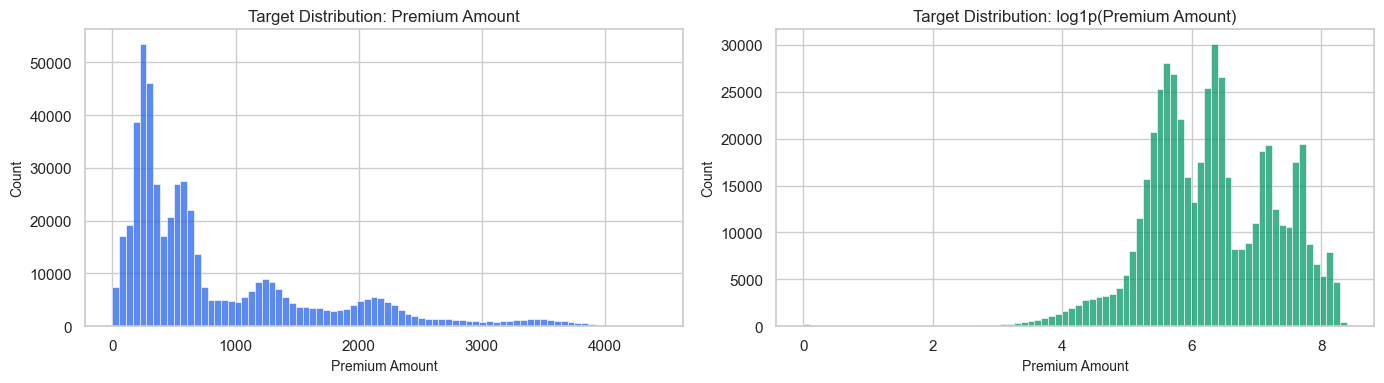

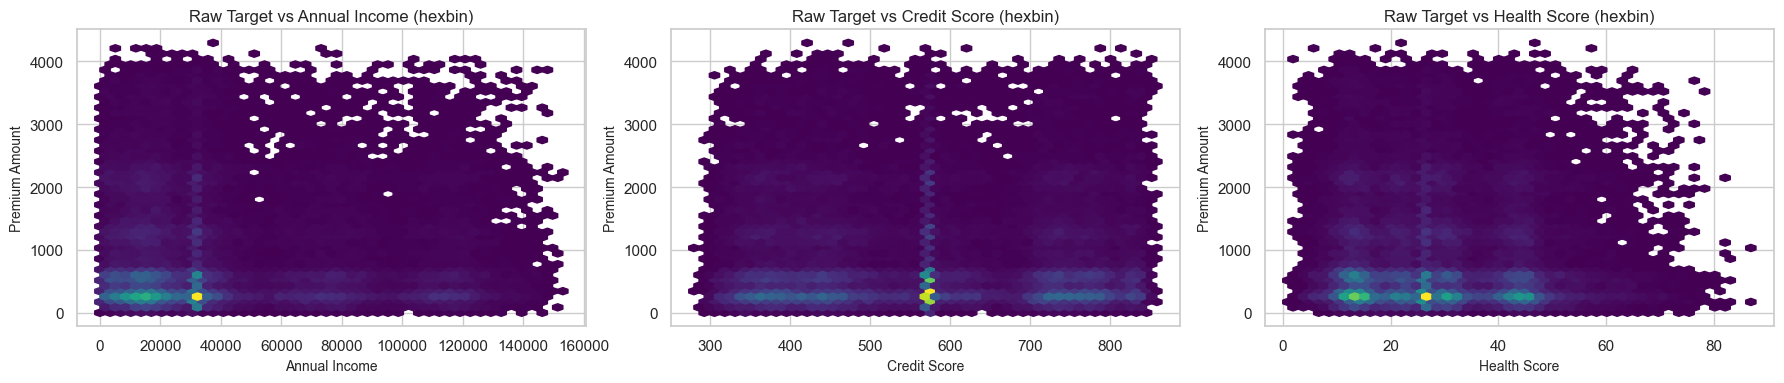

In [15]:
# Target-focused raw visuals (no processing dependency)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(eda_raw_train_df[TARGET_COL], bins=80, ax=axes[0], color="#2563eb")
axes[0].set_title("Target Distribution: Premium Amount")

sns.histplot(
    np.log1p(eda_raw_train_df[TARGET_COL]), bins=80, ax=axes[1], color="#059669"
)
axes[1].set_title("Target Distribution: log1p(Premium Amount)")
plt.tight_layout()
save_plot(fig, "target_raw_vs_log")
plt.show()

raw_scatter_df = (
    eda_raw_train_df[["Annual Income", "Credit Score", "Health Score", TARGET_COL]]
    .dropna()
    .sample(
        n=min(
            SAMPLE_SCATTER_N,
            eda_raw_train_df[
                ["Annual Income", "Credit Score", "Health Score", TARGET_COL]
            ]
            .dropna()
            .shape[0],
        ),
        random_state=EDA_RANDOM_SEED,
    )
)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col in zip(axes, ["Annual Income", "Credit Score", "Health Score"]):
    ax.hexbin(
        raw_scatter_df[col],
        raw_scatter_df[TARGET_COL],
        gridsize=45,
        cmap="viridis",
        mincnt=1,
    )
    ax.set_title(f"Raw Target vs {col} (hexbin)")
    ax.set_xlabel(col)
    ax.set_ylabel(TARGET_COL)
plt.tight_layout()
save_plot(fig, "target_numeric_hexbins")
plt.show()


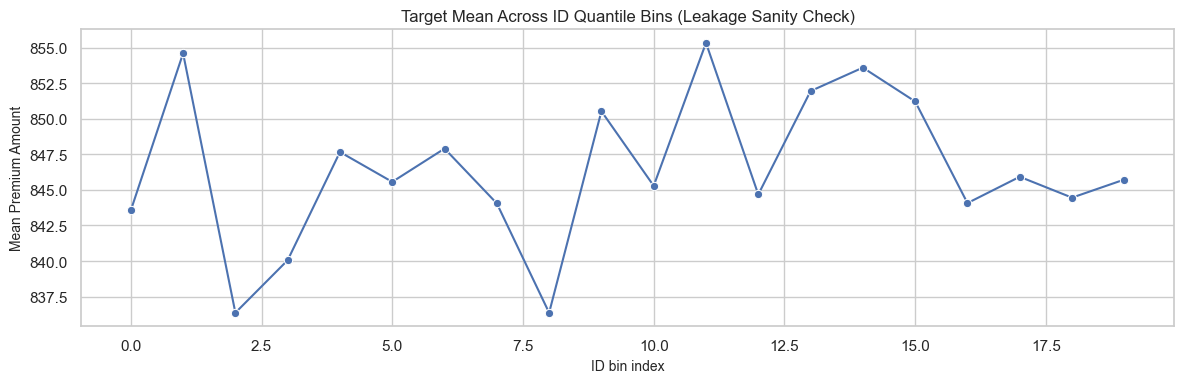

In [16]:
# Raw leakage/sanity visuals
id_target_df = eda_raw_train_df[["id", TARGET_COL]].copy()
id_target_df["id_bin"] = pd.qcut(id_target_df["id"], q=20, duplicates="drop")
id_target_trend_df = (
    id_target_df.groupby("id_bin", observed=True)[TARGET_COL].mean().reset_index()
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(
    data=id_target_trend_df, x=id_target_trend_df.index, y=TARGET_COL, marker="o", ax=ax
)
ax.set_title("Target Mean Across ID Quantile Bins (Leakage Sanity Check)")
ax.set_xlabel("ID bin index")
ax.set_ylabel(f"Mean {TARGET_COL}")
plt.tight_layout()
save_plot(fig, "id_target_leakage_trend")
plt.show()


# B. Processing Pipeline


In [17]:
# Phase B guardrail: raw data + shared schema must be loaded
required_phase_b = ["train_df", "test_df", "NUM_COLS", "CAT_COLS", "TARGET_COL"]
missing_phase_b = [name for name in required_phase_b if name not in globals()]
assert not missing_phase_b, (
    f"Run A. Setup + Load before B. Processing Pipeline. Missing: {missing_phase_b}"
)
print("Phase B guardrail passed.")


Phase B guardrail passed.


In [18]:
# === INS232 pandas processing pipeline ===
# Reuse shared constants from Phase A setup/load
required_schema_globals = [
    "ID_COL",
    "TARGET_COL",
    "NUM_COLS",
    "CAT_COLS",
    "LOG_COLS",
    "WINSOR_COLS",
]

missing_schema_globals = [
    name for name in required_schema_globals if name not in globals()
]
assert not missing_schema_globals, (
    "Missing shared schema constants. Run Phase A setup/load first: "
    f"{missing_schema_globals}"
)

TRAIN_EXPECTED = set([ID_COL, TARGET_COL] + NUM_COLS + CAT_COLS)
TEST_EXPECTED = set([ID_COL] + NUM_COLS + CAT_COLS)

missing_train_cols = sorted(TRAIN_EXPECTED - set(train_df.columns))
missing_test_cols = sorted(TEST_EXPECTED - set(test_df.columns))
assert not missing_train_cols, f"Missing train columns: {missing_train_cols}"
assert not missing_test_cols, f"Missing test columns: {missing_test_cols}"

print("Column contract checks passed.")


Column contract checks passed.


In [19]:
# Raw snapshots for auditability
train_raw_df = train_df.copy(deep=True)
test_raw_df = test_df.copy(deep=True)

# Working frames for processing
train_work_df = train_raw_df.copy(deep=True)
test_work_df = test_raw_df.copy(deep=True)

train_work_df = train_work_df.drop(columns=[ID_COL], errors="ignore")
test_work_df = test_work_df.drop(columns=[ID_COL], errors="ignore")

print("Raw snapshots and working dataframes created.")


Raw snapshots and working dataframes created.


In [20]:
# Normalize missing tokens and basic dtypes
MISSING_TOKENS = {"", "nan", "none", "null", "na", "n/a"}


def normalize_categorical(series: pd.Series) -> pd.Series:
    s = series.astype("string")
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()
    lowered = s.str.lower()
    s = s.mask(lowered.isin(MISSING_TOKENS), pd.NA)
    return s


raw_missing_mask_map = {}
for col in CAT_COLS:
    train_work_df[col] = normalize_categorical(train_work_df[col])
    test_work_df[col] = normalize_categorical(test_work_df[col])
    raw_missing_mask_map[col] = {
        "train": train_work_df[col].isna().copy(),
        "test": test_work_df[col].isna().copy(),
    }

for col in NUM_COLS + [TARGET_COL]:
    if col in train_work_df.columns:
        train_work_df[col] = pd.to_numeric(train_work_df[col], errors="coerce")
for col in NUM_COLS:
    if col in test_work_df.columns:
        test_work_df[col] = pd.to_numeric(test_work_df[col], errors="coerce")

print("Missing token normalization and dtype coercion complete.")


Missing token normalization and dtype coercion complete.


In [21]:
# Data quality sanitization (invalid values -> missing)
invalid_fix_counts = {}

# Explicit invalid rule from EDA
train_invalid_vehicle_age = train_work_df["Vehicle Age"] < 0
test_invalid_vehicle_age = test_work_df["Vehicle Age"] < 0
invalid_fix_counts["train_vehicle_age_lt_0"] = int(
    train_invalid_vehicle_age.fillna(False).sum()
)
invalid_fix_counts["test_vehicle_age_lt_0"] = int(
    test_invalid_vehicle_age.fillna(False).sum()
)
train_work_df.loc[train_invalid_vehicle_age, "Vehicle Age"] = np.nan
test_work_df.loc[test_invalid_vehicle_age, "Vehicle Age"] = np.nan

# Basic domain sanity checks
DOMAIN_RULES = {
    "Age": (0, 120),
    "Annual Income": (0, None),
    "Number of Dependents": (0, None),
    "Health Score": (0, None),
    "Previous Claims": (0, None),
    "Vehicle Age": (0, None),
    "Credit Score": (0, None),
    "Insurance Duration": (0, None),
}

for col, (min_val, max_val) in DOMAIN_RULES.items():
    for df_name, df in [("train", train_work_df), ("test", test_work_df)]:
        bad_mask = pd.Series(False, index=df.index)
        if min_val is not None:
            bad_mask = bad_mask | (df[col] < min_val)
        if max_val is not None:
            bad_mask = bad_mask | (df[col] > max_val)
        bad_count = int(bad_mask.fillna(False).sum())
        invalid_fix_counts[f"{df_name}_{col}_domain_invalid"] = bad_count
        df.loc[bad_mask, col] = np.nan

print("Data quality sanitization complete.")


Data quality sanitization complete.


In [22]:
# Missingness indicators from train pattern
feature_cols = NUM_COLS + CAT_COLS
missing_rate_train = train_work_df[feature_cols].isna().mean()
missing_indicator_cols = [col for col in feature_cols if missing_rate_train[col] > 0]

for col in missing_indicator_cols:
    ind_col = f"mis_{col}"
    train_work_df[ind_col] = train_work_df[col].isna().astype("int8")
    test_work_df[ind_col] = test_work_df[col].isna().astype("int8")

print(f"Created {len(missing_indicator_cols)} missingness indicator columns.")


Created 18 missingness indicator columns.


In [23]:
# Train-fitted imputation stats
# Numeric imputation: compare median vs iterative (train-fit only)
train_num_base = train_work_df[NUM_COLS].copy()
test_num_base = test_work_df[NUM_COLS].copy()

# Candidate 1: median
impute_medians = train_num_base.median(numeric_only=True)
train_num_median = train_num_base.fillna(impute_medians)
test_num_median = test_num_base.fillna(impute_medians)

observed_mask = train_num_base.notna()
median_mae = float(
    (train_num_median[observed_mask] - train_num_base[observed_mask])
    .abs()
    .stack()
    .mean()
)

iterative_mae = float("inf")
numeric_imputation_instability = False
numeric_imputation_warning_reason = ""

from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer

iterative_imputer = IterativeImputer(
    random_state=232, sample_posterior=False, max_iter=10
)
train_num_iter = pd.DataFrame(
    iterative_imputer.fit_transform(train_num_base),
    columns=NUM_COLS,
    index=train_num_base.index,
)
test_num_iter = pd.DataFrame(
    iterative_imputer.transform(test_num_base),
    columns=NUM_COLS,
    index=test_num_base.index,
)

iterative_mae = float(
    (train_num_iter[observed_mask] - train_num_base[observed_mask]).abs().stack().mean()
)

if (not np.isfinite(train_num_iter.to_numpy()).all()) or (
    not np.isfinite(test_num_iter.to_numpy()).all()
):
    numeric_imputation_instability = True
    numeric_imputation_warning_reason = "iterative produced non-finite values"

if (iterative_mae < median_mae) and (not numeric_imputation_instability):
    train_work_df[NUM_COLS] = train_num_iter
    test_work_df[NUM_COLS] = test_num_iter
    numeric_impute_choice = {
        "method": "iterative",
        "median_observed_mae": median_mae,
        "iterative_observed_mae": iterative_mae,
    }
else:
    train_work_df[NUM_COLS] = train_num_median
    test_work_df[NUM_COLS] = test_num_median
    numeric_impute_choice = {
        "method": "median",
        "median_observed_mae": median_mae,
        "iterative_observed_mae": iterative_mae,
    }

# Recommended strategy lock-in:
# preserve raw missingness as explicit "Missing" categories + missing indicators.
CATEGORICAL_MISSING_STRATEGY = "preserve_missing_labels"
ABLATION_TARGET_COLS = ["Occupation", "Marital Status", "Location"]

for col in CAT_COLS:
    train_work_df[col] = train_work_df[col].astype("string").fillna("Missing")
    test_work_df[col] = test_work_df[col].astype("string").fillna("Missing")

hierarchical_fill_stats = {
    "strategy": CATEGORICAL_MISSING_STRATEGY,
    "applied_columns": [],
    "note": "Hierarchical categorical fill disabled in main pipeline.",
}

print(
    "Imputation complete with train-fit numeric selection and categorical Missing-label preservation."
)


Imputation complete with train-fit numeric selection and categorical Missing-label preservation.


In [24]:
# Categorical canonicalization + stable train vocabulary
CANONICAL_LEVELS = {
    "Gender": ["Female", "Male", "Missing", "Unknown"],
    "Marital Status": ["Divorced", "Married", "Single", "Missing", "Unknown"],
    "Education Level": [
        "High School",
        "Bachelor's",
        "Master's",
        "PhD",
        "Missing",
        "Unknown",
    ],
    "Occupation": ["Employed", "Self-Employed", "Unemployed", "Missing", "Unknown"],
    "Location": ["Rural", "Suburban", "Urban", "Missing", "Unknown"],
    "Policy Type": ["Basic", "Comprehensive", "Premium", "Missing", "Unknown"],
    "Customer Feedback": ["Average", "Good", "Poor", "Missing", "Unknown"],
    "Smoking Status": ["No", "Yes", "Missing", "Unknown"],
    "Exercise Frequency": [
        "Daily",
        "Weekly",
        "Monthly",
        "Rarely",
        "Missing",
        "Unknown",
    ],
    "Property Type": ["Apartment", "Condo", "House", "Missing", "Unknown"],
}

cat_vocab_map = {}
unseen_category_replacements = {}
missing_label_rates = {}
unknown_label_rates = {}

for col in CAT_COLS:
    canonical = CANONICAL_LEVELS[col]
    lookup = {v.lower(): v for v in canonical}
    lookup["master’s"] = "Master's"
    lookup["missing"] = "Missing"

    def canonicalize(s: pd.Series, orig_missing_mask: pd.Series) -> pd.Series:
        base = s.astype("string").str.strip()
        low = base.str.lower()
        mapped = low.map(lookup)
        mapped = mapped.fillna("Unknown")
        mapped = mapped.mask(orig_missing_mask, "Missing")
        return mapped

    train_work_df[col] = canonicalize(
        train_work_df[col], raw_missing_mask_map[col]["train"]
    )
    test_work_df[col] = canonicalize(
        test_work_df[col], raw_missing_mask_map[col]["test"]
    )

    train_vocab = sorted(train_work_df[col].dropna().unique().tolist())
    for label in ["Missing", "Unknown"]:
        if label not in train_vocab:
            train_vocab.append(label)
    cat_vocab_map[col] = train_vocab

    unseen_mask = ~test_work_df[col].isin(train_vocab)
    unseen_category_replacements[col] = int(unseen_mask.sum())
    test_work_df.loc[unseen_mask, col] = "Unknown"

    dtype = CategoricalDtype(categories=train_vocab, ordered=False)
    train_work_df[col] = train_work_df[col].astype(dtype)
    test_work_df[col] = test_work_df[col].astype(dtype)

    missing_label_rates[col] = {
        "train": float((train_work_df[col].astype("string") == "Missing").mean() * 100),
        "test": float((test_work_df[col].astype("string") == "Missing").mean() * 100),
    }
    unknown_label_rates[col] = {
        "train": float((train_work_df[col].astype("string") == "Unknown").mean() * 100),
        "test": float((test_work_df[col].astype("string") == "Unknown").mean() * 100),
    }

print("Categorical canonicalization and train-vocab casting complete.")


Categorical canonicalization and train-vocab casting complete.


In [25]:
# Skew-friendly transforms and outlier clipping
for col in LOG_COLS:
    train_work_df[f"log1p_{col}"] = np.log1p(
        np.clip(train_work_df[col], a_min=0, a_max=None)
    )
    test_work_df[f"log1p_{col}"] = np.log1p(
        np.clip(test_work_df[col], a_min=0, a_max=None)
    )

winsor_bounds_map = {}
for col in WINSOR_COLS:
    q_low = float(train_work_df[col].quantile(0.005))
    q_high = float(train_work_df[col].quantile(0.995))
    winsor_bounds_map[col] = {"q_low_0p5": q_low, "q_high_99p5": q_high}
    train_work_df[f"clip_{col}"] = train_work_df[col].clip(lower=q_low, upper=q_high)
    test_work_df[f"clip_{col}"] = test_work_df[col].clip(lower=q_low, upper=q_high)

print("log1p and train-quantile clipping features created.")


log1p and train-quantile clipping features created.


In [26]:
# Safe derived features + bins
train_work_df["is_zero_income"] = (train_work_df["Annual Income"] <= 0).astype("int8")
test_work_df["is_zero_income"] = (test_work_df["Annual Income"] <= 0).astype("int8")

zero_income_counts = {
    "train_is_zero_income": int(train_work_df["is_zero_income"].sum()),
    "test_is_zero_income": int(test_work_df["is_zero_income"].sum()),
}

train_work_df["income_per_dependent"] = train_work_df["Annual Income"] / (
    train_work_df["Number of Dependents"] + 1
)
test_work_df["income_per_dependent"] = test_work_df["Annual Income"] / (
    test_work_df["Number of Dependents"] + 1
)

train_claim_denom = train_work_df["Insurance Duration"].replace(0, np.nan)
test_claim_denom = test_work_df["Insurance Duration"].replace(0, np.nan)
train_work_df["claims_per_year"] = (
    train_work_df["Previous Claims"] / train_claim_denom
).fillna(0.0)
test_work_df["claims_per_year"] = (
    test_work_df["Previous Claims"] / test_claim_denom
).fillna(0.0)

train_income_floor_for_ratio = train_work_df["Annual Income"].clip(lower=1000.0)
test_income_floor_for_ratio = test_work_df["Annual Income"].clip(lower=1000.0)
train_work_df["credit_income_ratio"] = (
    train_work_df["Credit Score"] / train_income_floor_for_ratio
)
test_work_df["credit_income_ratio"] = (
    test_work_df["Credit Score"] / test_income_floor_for_ratio
)

derived_clip_stats = {}
for col in ["income_per_dependent", "credit_income_ratio"]:
    q_low = float(train_work_df[col].quantile(0.005))
    q_high = float(train_work_df[col].quantile(0.995))
    winsor_bounds_map[col] = {"q_low_0p5": q_low, "q_high_99p5": q_high}

    train_before = train_work_df[col].copy()
    test_before = test_work_df[col].copy()
    train_work_df[col] = train_work_df[col].clip(lower=q_low, upper=q_high)
    test_work_df[col] = test_work_df[col].clip(lower=q_low, upper=q_high)

    derived_clip_stats[f"train_{col}_changed_pct"] = float(
        (train_work_df[col] != train_before).mean() * 100
    )
    derived_clip_stats[f"test_{col}_changed_pct"] = float(
        (test_work_df[col] != test_before).mean() * 100
    )

BIN_SPECS = {
    "age_band": ("Age", [0, 25, 35, 45, 55, 65, np.inf]),
    "income_band": ("Annual Income", [0, 10000, 30000, 60000, 100000, np.inf]),
    "credit_band": ("Credit Score", [0, 400, 550, 700, 800, np.inf]),
    "vehicle_age_band": ("Vehicle Age", [0, 3, 7, 12, 20, np.inf]),
}

for band_col, (base_col, edges) in BIN_SPECS.items():
    train_work_df[band_col] = pd.cut(
        train_work_df[base_col], bins=edges, include_lowest=True
    )
    test_work_df[band_col] = pd.cut(
        test_work_df[base_col], bins=edges, include_lowest=True
    )

print(
    "Derived ratio features, stabilization, and fixed-bin categorical features created."
)


Derived ratio features, stabilization, and fixed-bin categorical features created.


In [27]:
# Final assembly and assertions
train_processed_df = train_work_df.copy()
test_processed_df = test_work_df.copy()

base_cols = [c for c in (NUM_COLS + CAT_COLS) if c in train_processed_df.columns]
indicator_cols = sorted([c for c in train_processed_df.columns if c.startswith("mis_")])
log_cols = sorted([c for c in train_processed_df.columns if c.startswith("log1p_")])
clip_cols = sorted([c for c in train_processed_df.columns if c.startswith("clip_")])
derived_cols = [
    "is_zero_income",
    "income_per_dependent",
    "claims_per_year",
    "credit_income_ratio",
]
bin_cols = ["age_band", "income_band", "credit_band", "vehicle_age_band"]

ordered_common_cols = [
    *base_cols,
    *indicator_cols,
    *log_cols,
    *clip_cols,
    *derived_cols,
    *bin_cols,
]
ordered_common_cols = [
    c for c in ordered_common_cols if c in train_processed_df.columns
]

train_processed_df = train_processed_df[[*ordered_common_cols, TARGET_COL]]
test_processed_df = test_processed_df[ordered_common_cols]

assert TARGET_COL in train_processed_df.columns
assert TARGET_COL not in test_processed_df.columns
assert list(train_processed_df.drop(columns=[TARGET_COL]).columns) == list(
    test_processed_df.columns
)

for col in CAT_COLS:
    assert str(train_processed_df[col].dtype) == "category", (
        f"{col} is not category dtype"
    )
    assert str(test_processed_df[col].dtype) == "category", (
        f"{col} is not category dtype"
    )

    allowed = set(cat_vocab_map[col])
    train_vals = set(train_processed_df[col].astype("string").unique())
    test_vals = set(test_processed_df[col].astype("string").unique())
    assert train_vals.issubset(allowed), f"Unexpected train category values in {col}"
    assert test_vals.issubset(allowed), f"Unexpected test category values in {col}"

engineered_numeric_cols = derived_cols + log_cols + clip_cols
assert train_processed_df[engineered_numeric_cols].isna().sum().sum() == 0
assert test_processed_df[engineered_numeric_cols].isna().sum().sum() == 0
assert np.isfinite(train_processed_df[engineered_numeric_cols].to_numpy()).all()
assert np.isfinite(test_processed_df[engineered_numeric_cols].to_numpy()).all()
assert str(train_processed_df["is_zero_income"].dtype) == "int8"
assert (
    train_processed_df["credit_income_ratio"].max()
    <= winsor_bounds_map["credit_income_ratio"]["q_high_99p5"] + 1e-12
)

if "cat_drift_df" not in globals():
    cat_drift_df = pd.DataFrame(
        columns=[
            "feature",
            "max_abs_category_share_delta_pct",
            "mean_abs_category_share_delta_pct",
            "drift_flag_high",
            "drift_flag_medium",
        ]
    )
expected_drift_cols = {
    "feature",
    "max_abs_category_share_delta_pct",
    "mean_abs_category_share_delta_pct",
    "drift_flag_high",
    "drift_flag_medium",
}
assert expected_drift_cols.issubset(set(cat_drift_df.columns)), (
    "cat_drift_df missing expected drift columns"
)

# Encoding-ready branch for future linear models (train-fit only)
linear_encoder = None
linear_feature_names = []
train_linear_encoded_df = None
test_linear_encoded_df = None

from sklearn.preprocessing import OneHotEncoder

# Numeric + engineered features for linear branch
linear_numeric_cols = [
    c
    for c in ordered_common_cols
    if (c not in CAT_COLS) and (str(train_processed_df[c].dtype) != "category")
]

linear_encoder = OneHotEncoder(
    handle_unknown="infrequent_if_exist",
    min_frequency=0.005,
    sparse_output=False,
)

train_cat_encoded = linear_encoder.fit_transform(
    train_processed_df[CAT_COLS].astype("string")
)
test_cat_encoded = linear_encoder.transform(
    test_processed_df[CAT_COLS].astype("string")
)

linear_feature_names = linear_encoder.get_feature_names_out(CAT_COLS).tolist()

train_linear_encoded_df = pd.concat(
    [
        train_processed_df[linear_numeric_cols].reset_index(drop=True),
        pd.DataFrame(train_cat_encoded, columns=linear_feature_names),
    ],
    axis=1,
)
train_linear_encoded_df[TARGET_COL] = train_processed_df[TARGET_COL].reset_index(
    drop=True
)

test_linear_encoded_df = pd.concat(
    [
        test_processed_df[linear_numeric_cols].reset_index(drop=True),
        pd.DataFrame(test_cat_encoded, columns=linear_feature_names),
    ],
    axis=1,
)

# Train-fit discipline assertions
assert train_cat_encoded.shape[1] == test_cat_encoded.shape[1]
assert TARGET_COL in train_linear_encoded_df.columns
assert TARGET_COL not in test_linear_encoded_df.columns

print("Final dataframe assembly and assertions passed.")


Final dataframe assembly and assertions passed.


In [28]:
# Processing QA report
before_missing_pct = (
    train_raw_df.drop(columns=[ID_COL], errors="ignore").isna().mean().mul(100)
)
after_missing_pct = train_processed_df.isna().mean().mul(100)
all_cols = sorted(set(before_missing_pct.index) | set(after_missing_pct.index))

missing_rows = []
for col in all_cols:
    missing_rows.append(
        {
            "section": "missingness",
            "feature": col,
            "metric": "missing_pct_before",
            "value": float(before_missing_pct.get(col, np.nan)),
        }
    )
    missing_rows.append(
        {
            "section": "missingness",
            "feature": col,
            "metric": "missing_pct_after",
            "value": float(after_missing_pct.get(col, np.nan)),
        }
    )

invalid_rows = [
    {"section": "invalid_fix", "feature": k, "metric": "count", "value": float(v)}
    for k, v in invalid_fix_counts.items()
]

zero_income_rows = [
    {
        "section": "derived_fix",
        "feature": k,
        "metric": "count",
        "value": float(v),
    }
    for k, v in zero_income_counts.items()
]

unseen_rows = [
    {
        "section": "test_unseen_category",
        "feature": k,
        "metric": "replaced_with_unknown",
        "value": float(v),
    }
    for k, v in unseen_category_replacements.items()
]

derived_clip_rows = [
    {
        "section": "derived_clip",
        "feature": k,
        "metric": "changed_pct",
        "value": float(v),
    }
    for k, v in derived_clip_stats.items()
]

label_rows = []
for col in ["Occupation", "Marital Status", "Location"]:
    label_rows.append(
        {
            "section": "categorical_label_share",
            "feature": col,
            "metric": "train_missing_label_pct",
            "value": float(missing_label_rates[col]["train"]),
        }
    )
    label_rows.append(
        {
            "section": "categorical_label_share",
            "feature": col,
            "metric": "train_unknown_label_pct",
            "value": float(unknown_label_rates[col]["train"]),
        }
    )

# Drift gate summary computed from current processed outputs (informational only)
drift_eval_rows = []
for col in CAT_COLS:
    train_prop = train_processed_df[col].astype("string").value_counts(normalize=True)
    test_prop = test_processed_df[col].astype("string").value_counts(normalize=True)
    aligned = pd.concat(
        [train_prop.rename("train"), test_prop.rename("test")], axis=1
    ).fillna(0)
    aligned["abs_delta"] = (aligned["train"] - aligned["test"]).abs()
    max_delta = float(aligned["abs_delta"].max() * 100)
    drift_eval_rows.append(
        {
            "feature": col,
            "max_abs_category_share_delta_pct": max_delta,
            "drift_flag_high": int(max_delta >= 2.0),
            "drift_flag_medium": int(1.0 <= max_delta < 2.0),
        }
    )

drift_eval_df = pd.DataFrame(drift_eval_rows)
drift_gate_rows = [
    {
        "section": "drift_gate",
        "feature": "categorical",
        "metric": "high_flag_count",
        "value": float(drift_eval_df["drift_flag_high"].sum()),
    },
    {
        "section": "drift_gate",
        "feature": "categorical",
        "metric": "medium_flag_count",
        "value": float(drift_eval_df["drift_flag_medium"].sum()),
    },
]

numeric_impute_rows = [
    {
        "section": "numeric_imputation",
        "feature": "NUM_COLS",
        "metric": "chosen_method",
        "value": 1.0 if numeric_impute_choice.get("method") == "iterative" else 0.0,
    },
    {
        "section": "numeric_imputation",
        "feature": "NUM_COLS",
        "metric": "median_observed_mae",
        "value": float(numeric_impute_choice.get("median_observed_mae", np.nan)),
    },
    {
        "section": "numeric_imputation",
        "feature": "NUM_COLS",
        "metric": "iterative_observed_mae",
        "value": float(numeric_impute_choice.get("iterative_observed_mae", np.nan)),
    },
]

linear_rows = []
if train_linear_encoded_df is not None and test_linear_encoded_df is not None:
    linear_rows = [
        {
            "section": "linear_encoding",
            "feature": "shape",
            "metric": "n_features_before",
            "value": float(len(train_processed_df.columns) - 1),
        },
        {
            "section": "linear_encoding",
            "feature": "shape",
            "metric": "n_features_after",
            "value": float(len(train_linear_encoded_df.columns) - 1),
        },
    ]

numeric_check_cols = (
    NUM_COLS
    + [
        "income_per_dependent",
        "claims_per_year",
        "credit_income_ratio",
    ]
    + [f"log1p_{c}" for c in LOG_COLS]
    + [f"clip_{c}" for c in WINSOR_COLS]
)

sanity_rows = []
for col in numeric_check_cols:
    sanity_rows.append(
        {
            "section": "numeric_sanity",
            "feature": col,
            "metric": "train_min",
            "value": float(train_processed_df[col].min()),
        }
    )
    sanity_rows.append(
        {
            "section": "numeric_sanity",
            "feature": col,
            "metric": "train_max",
            "value": float(train_processed_df[col].max()),
        }
    )

processing_report_df = pd.DataFrame(
    missing_rows
    + invalid_rows
    + zero_income_rows
    + unseen_rows
    + derived_clip_rows
    + label_rows
    + drift_gate_rows
    + numeric_impute_rows
    + linear_rows
    + sanity_rows
)

display(processing_report_df.head(20))
print("processing_report_df rows:", len(processing_report_df))


,section,feature,metric,value
0,missingness,Age,missing_pct_before,11.489038
1,missingness,Age,missing_pct_after,0.000000
2,missingness,Annual Income,missing_pct_before,29.428846
3,missingness,Annual Income,missing_pct_after,0.000000
4,missingness,Credit Score,missing_pct_before,16.081538
5,missingness,Credit Score,missing_pct_after,0.000000
6,missingness,Customer Feedback,missing_pct_before,17.125769
7,missingness,Customer Feedback,missing_pct_after,0.000000
8,missingness,Education Level,missing_pct_before,16.140962
9,missingness,Education Level,missing_pct_after,0.000000


processing_report_df rows: 203


In [29]:
# Notebook-ready handoff
print("train_processed_df shape:", train_processed_df.shape)
print("test_processed_df shape:", test_processed_df.shape)

display(train_processed_df.head())
display(test_processed_df.head())

display(train_processed_df.dtypes.astype(str).value_counts())

train_processed_df shape: (520000, 56)
test_processed_df shape: (80000, 55)


,Age,Annual Income,Number of Dependents,Health Score,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Gender,Marital Status,Education Level,Occupation,Location,Policy Type,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,mis_Age,mis_Annual Income,mis_Credit Score,mis_Customer Feedback,mis_Education Level,mis_Exercise Frequency,mis_Gender,mis_Health Score,mis_Insurance Duration,mis_Location,mis_Marital Status,mis_Number of Dependents,mis_Occupation,mis_Policy Type,mis_Previous Claims,mis_Property Type,mis_Smoking Status,mis_Vehicle Age,log1p_Annual Income,log1p_Credit Score,log1p_Health Score,clip_Age,clip_Annual Income,clip_Credit Score,clip_Health Score,clip_Insurance Duration,clip_Number of Dependents,clip_Previous Claims,clip_Vehicle Age,is_zero_income,income_per_dependent,claims_per_year,credit_income_ratio,age_band,income_band,credit_band,vehicle_age_band,Premium Amount
0,52.0,29855.435,1.0,46.39,1.0,19.0,770.12,5.0,Missing,Married,Missing,Missing,Suburban,Comprehensive,Good,Yes,Monthly,House,0,1,0,0,1,0,1,0,1,0,0,0,1,0,0,0,0,0,10.304156,6.647844,3.858411,52.0,29855.435,770.12,46.39,5.0,1.0,1.0,19.0,0,14927.7175,0.200000,0.025795,"(45.0, 55.0]","(10000.0, 30000.0]","(700.0, 800.0]","(12.0, 20.0]",458.84
1,54.0,20482.060,1.0,27.70,1.0,7.0,704.13,5.0,Male,Missing,Master's,Missing,Suburban,Missing,Average,Yes,Weekly,Condo,0,0,0,0,0,0,0,0,0,0,1,1,1,1,0,0,0,1,9.927353,6.558382,3.356897,54.0,20482.060,704.13,27.70,5.0,1.0,1.0,7.0,0,10241.0300,0.200000,0.034378,"(45.0, 55.0]","(10000.0, 30000.0]","(700.0, 800.0]","(3.0, 7.0]",200.05
2,27.0,17775.080,0.0,29.28,0.0,12.0,574.23,1.0,Female,Divorced,Missing,Self-Employed,Urban,Premium,Average,Yes,Weekly,Missing,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,9.785609,6.354770,3.410487,27.0,17775.080,574.23,29.28,1.0,0.0,0.0,12.0,0,17775.0800,0.000000,0.032305,"(25.0, 35.0]","(10000.0, 30000.0]","(550.0, 700.0]","(7.0, 12.0]",223.93
3,47.0,58531.020,0.0,44.32,0.0,12.0,419.07,5.0,Female,Married,Bachelor's,Self-Employed,Urban,Missing,Good,No,Daily,Missing,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,10.977329,6.040421,3.813748,47.0,58531.020,419.07,44.32,5.0,0.0,0.0,12.0,0,58531.0200,0.000000,0.007160,"(45.0, 55.0]","(30000.0, 60000.0]","(400.0, 550.0]","(7.0, 12.0]",278.17
4,38.0,86930.270,1.0,68.03,1.0,14.0,650.90,9.0,Female,Single,Master's,Self-Employed,Rural,Basic,Good,Missing,Daily,House,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,11.372873,6.479891,4.234541,38.0,86930.270,650.90,68.03,9.0,1.0,1.0,14.0,0,43465.1350,0.111111,0.007488,"(35.0, 45.0]","(60000.0, 100000.0]","(550.0, 700.0]","(12.0, 20.0]",306.93


,Age,Annual Income,Number of Dependents,Health Score,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Gender,Marital Status,Education Level,Occupation,Location,Policy Type,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,mis_Age,mis_Annual Income,mis_Credit Score,mis_Customer Feedback,mis_Education Level,mis_Exercise Frequency,mis_Gender,mis_Health Score,mis_Insurance Duration,mis_Location,mis_Marital Status,mis_Number of Dependents,mis_Occupation,mis_Policy Type,mis_Previous Claims,mis_Property Type,mis_Smoking Status,mis_Vehicle Age,log1p_Annual Income,log1p_Credit Score,log1p_Health Score,clip_Age,clip_Annual Income,clip_Credit Score,clip_Health Score,clip_Insurance Duration,clip_Number of Dependents,clip_Previous Claims,clip_Vehicle Age,is_zero_income,income_per_dependent,claims_per_year,credit_income_ratio,age_band,income_band,credit_band,vehicle_age_band
0,53.0,35635.490,0.0,42.76,1.0,0.0,724.56,7.0,Male,Married,PhD,Self-Employed,Suburban,Premium,Good,Yes,Weekly,House,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,10.481125,6.586944,3.778720,53.0,35635.490,724.56,42.76,7.0,0.0,1.0,0.0,0,35635.490000,0.142857,0.020333,"(45.0, 55.0]","(30000.0, 60000.0]","(700.0, 800.0]","(-0.001, 3.0]"
1,63.0,134117.550,3.0,43.93,1.0,18.0,445.92,5.0,Male,Missing,High School,Missing,Urban,Missing,Average,No,Weekly,Apartment,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0,11.806479,6.102380,3.805106,63.0,134117.550,445.92,43.93,5.0,3.0,1.0,18.0,0,33529.387500,0.200000,0.003325,"(55.0, 65.0]","(100000.0, inf]","(400.0, 550.0]","(12.0, 20.0]"
2,46.0,111860.170,2.0,27.53,0.0,4.0,574.23,9.0,Male,Missing,High School,Employed,Suburban,Missing,Average,Yes,Daily,Missing,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,11.625014,6.354770,3.350956,46.0,111860.170,574.23,27.53,9.0,2.0,0.0,4.0,0,37286.723333,0.000000,0.005133,"(45.0, 55.0]","(100000.0, inf]","(550.0, 700.0]","(3.0, 7.0]"
3,57.0,3821.120,1.0,24.59,1.0,7.0,333.00,3.0,Female,Married,Master's,Employed,Rural,Comprehensive,Average,Yes,Daily,Missing,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,8.248561,5.811141,3.242202,57.0,3821.120,333.00,24.59,3.0,1.0,1.0,7.0,0,1910.560000,0.333333,0.087147,"(55.0, 65.0]","(-0.001, 10000.0]","(-0.001, 400.0]","(3.0, 7.0]"
4,60.0,29855.435,4.0,38.77,1.0,19.0,811.33,3.0,Female,Single,Missing,Unemployed,Missing,Comprehensive,Good,Yes,Monthly,Apartment,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,10.304156,6.699907,3.683113,60.0,29855.435,811.33,38.77,3.0,4.0,1.0,19.0,0,5971.087000,0.333333,0.027175,"(55.0, 65.0]","(10000.0, 30000.0]","(800.0, inf]","(12.0, 20.0]"


float64     23
int8        19
category    14
Name: count, dtype: int64

# C. Post-Processing QA + Issue Report + Outputs Index


In [30]:
# Phase C guardrail: processed dataframes must exist
required_phase_c = ["train_processed_df", "test_processed_df", "TARGET_COL", "CAT_COLS"]
missing_phase_c = [name for name in required_phase_c if name not in globals()]
assert not missing_phase_c, (
    "Run B. Processing Pipeline before C. Post-Processing QA. Missing: "
    f"{missing_phase_c}"
)

eda_processed_train_df = train_processed_df.copy(deep=True)
eda_processed_test_df = test_processed_df.copy(deep=True)

print("Phase C guardrail passed.")


Phase C guardrail passed.


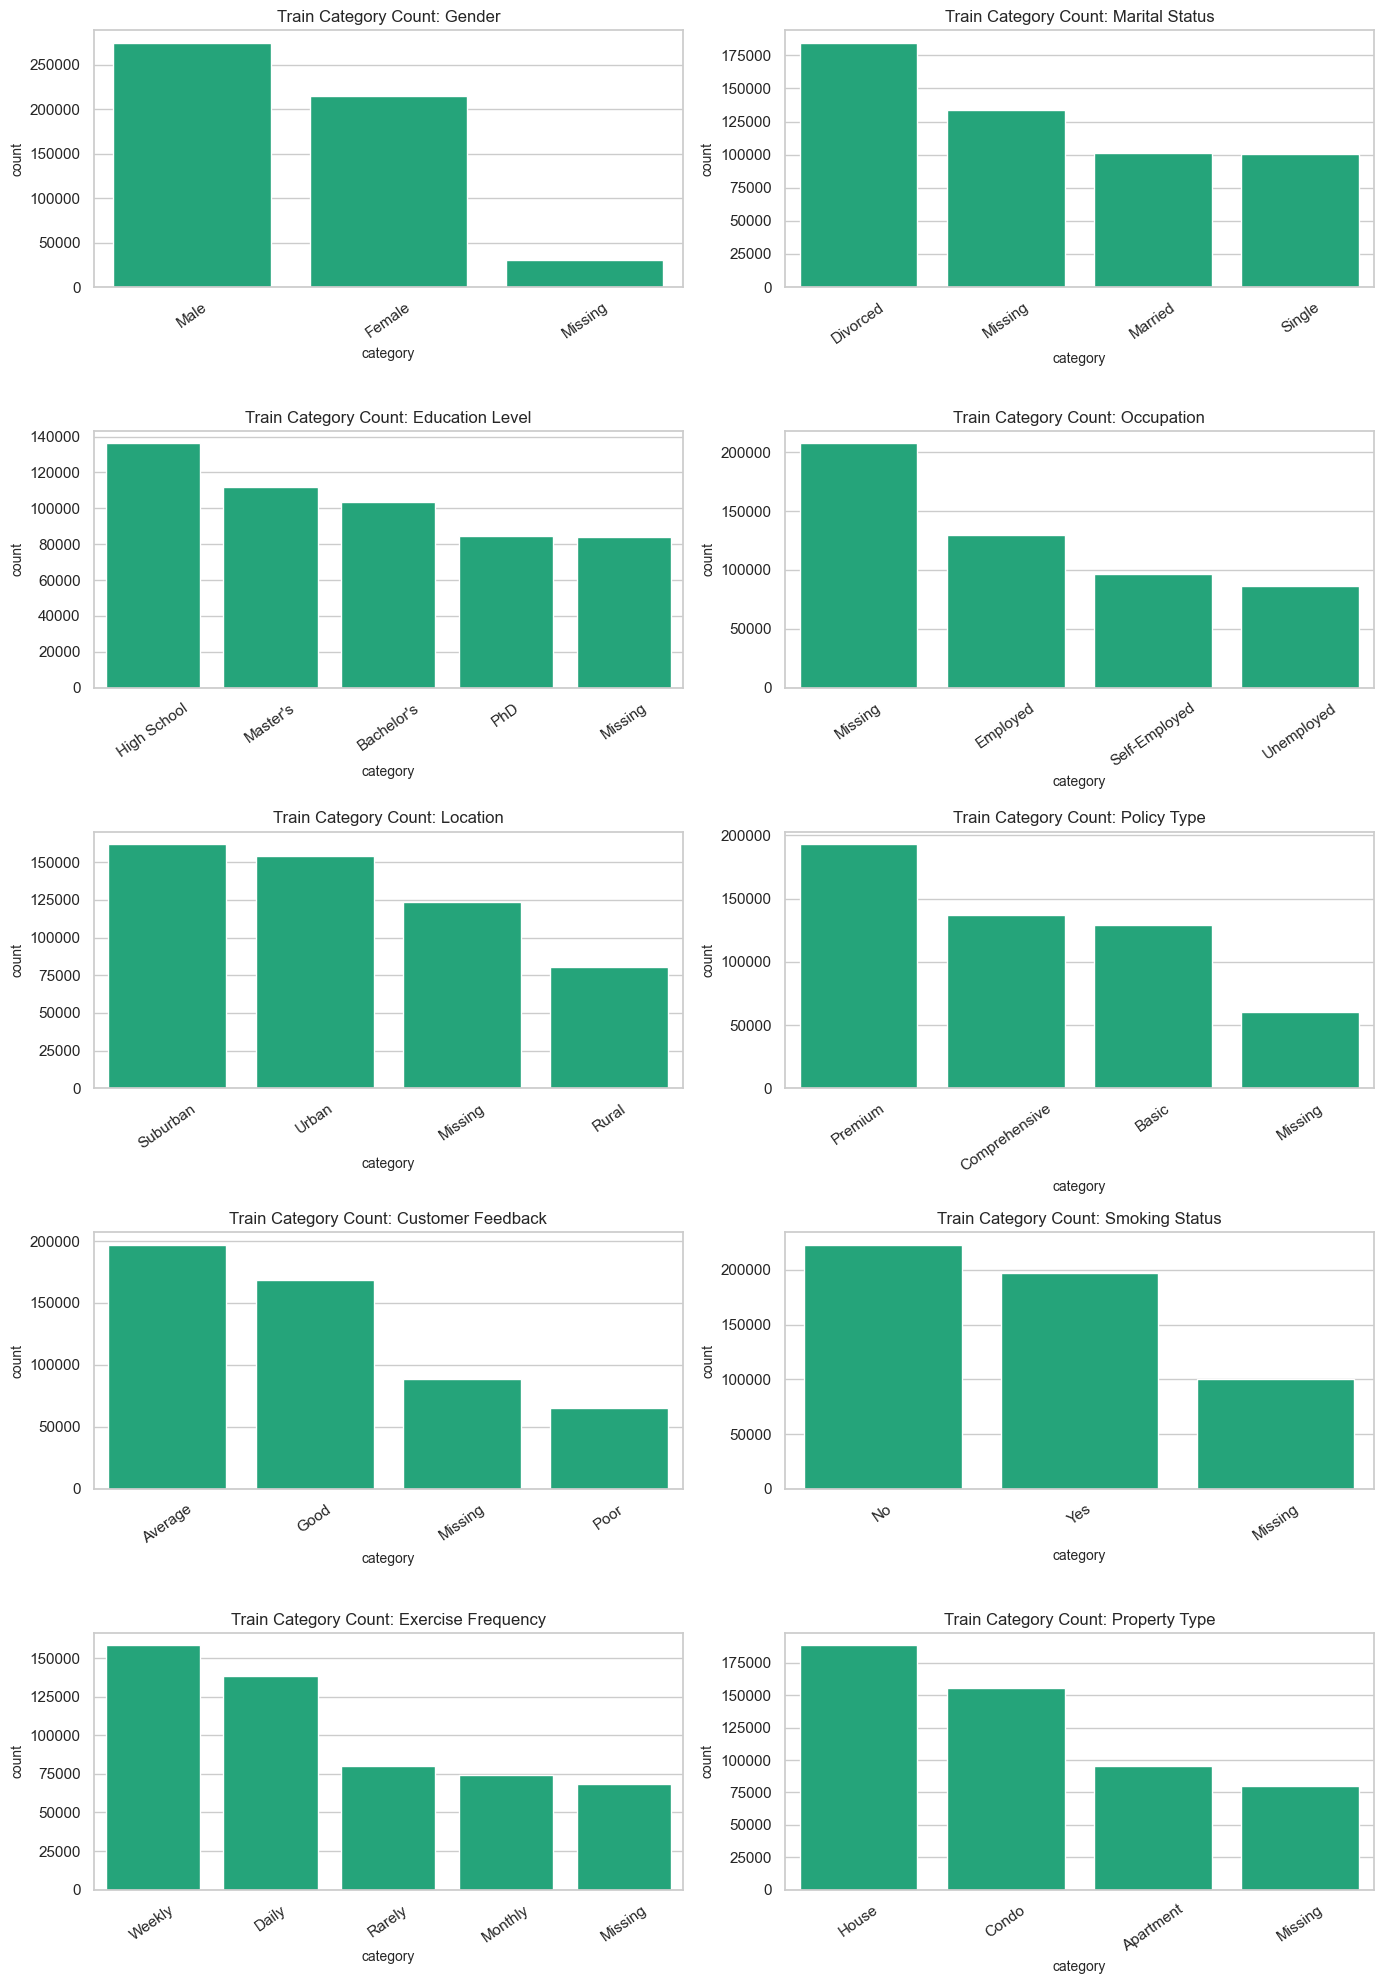

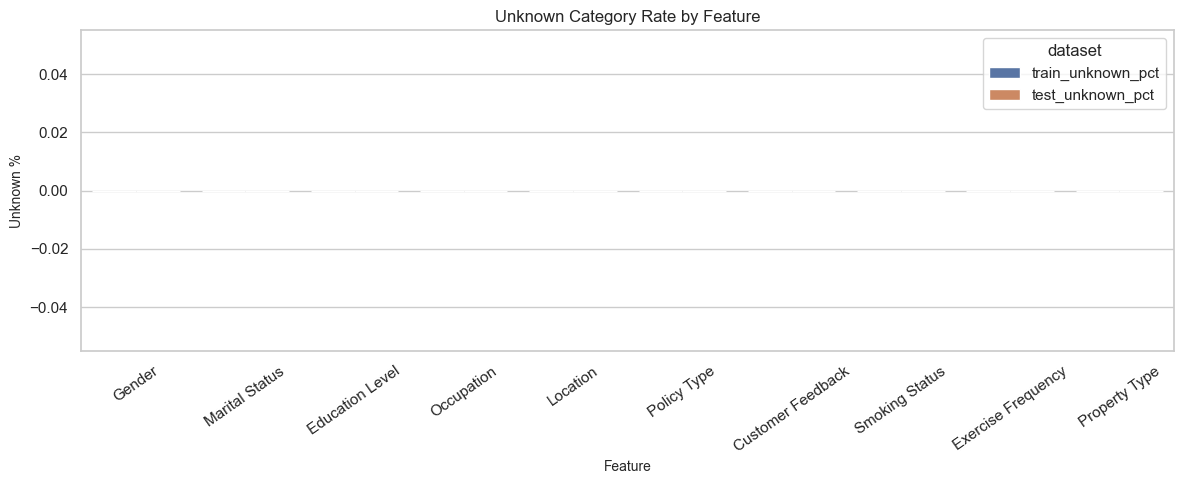

In [31]:
# Categorical distributions and unknown-rate overview
fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()

for idx, col in enumerate(CAT_COLS):
    train_counts = (
        eda_processed_train_df[col]
        .astype("string")
        .value_counts(dropna=False)
        .rename_axis("category")
        .reset_index(name="count")
    )
    sns.barplot(
        data=train_counts, x="category", y="count", ax=axes[idx], color="#10b981"
    )
    axes[idx].set_title(f"Train Category Count: {col}")
    axes[idx].tick_params(axis="x", rotation=35)

for idx in range(len(CAT_COLS), len(axes)):
    axes[idx].axis("off")

plt.tight_layout()
save_plot(fig, "category_counts_grid")
plt.show()

unknown_rows = []
for col in CAT_COLS:
    train_unknown = float(
        (eda_processed_train_df[col].astype("string") == "Unknown").mean() * 100
    )
    test_unknown = float(
        (eda_processed_test_df[col].astype("string") == "Unknown").mean() * 100
    )
    unknown_rows.append(
        {
            "feature": col,
            "train_unknown_pct": train_unknown,
            "test_unknown_pct": test_unknown,
        }
    )

unknown_df = pd.DataFrame(unknown_rows)
unknown_long_df = unknown_df.melt(
    id_vars="feature",
    value_vars=["train_unknown_pct", "test_unknown_pct"],
    var_name="dataset",
    value_name="unknown_pct",
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=unknown_long_df, x="feature", y="unknown_pct", hue="dataset", ax=ax)
ax.set_title("Unknown Category Rate by Feature")
ax.set_ylabel("Unknown %")
ax.set_xlabel("Feature")
plt.xticks(rotation=35)
plt.tight_layout()
save_plot(fig, "unknown_rate_by_feature")
plt.show()


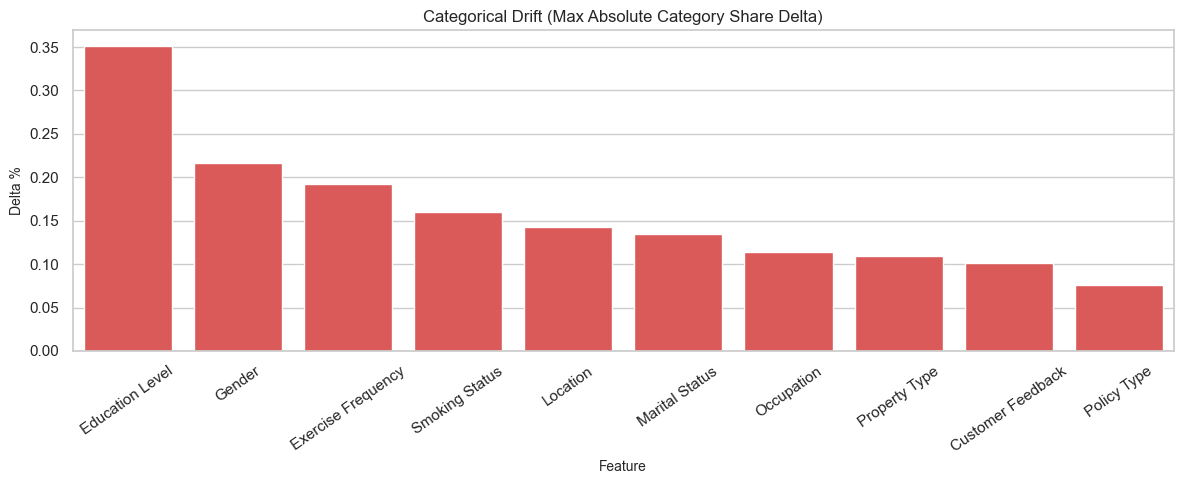

,feature,max_abs_category_share_delta_pct,mean_abs_category_share_delta_pct,drift_flag_high,drift_flag_medium
2,Education Level,0.351538,0.140615,0,0
0,Gender,0.216442,0.144295,0,0
8,Exercise Frequency,0.192019,0.092846,0,0
7,Smoking Status,0.160385,0.106923,0,0
4,Location,0.143269,0.076106,0,0
1,Marital Status,0.135000,0.087933,0,0
3,Occupation,0.113942,0.065865,0,0
9,Property Type,0.109808,0.054904,0,0
6,Customer Feedback,0.101058,0.061875,0,0
5,Policy Type,0.076538,0.038269,0,0


In [32]:
# Categorical train-test proportion drift (max absolute delta)
# Observe drift only; do not apply drift-based remapping/correction when drift is low.
drift_rows = []
for col in CAT_COLS:
    train_prop = (
        eda_processed_train_df[col].astype("string").value_counts(normalize=True)
    )
    test_prop = eda_processed_test_df[col].astype("string").value_counts(normalize=True)
    aligned = pd.concat(
        [train_prop.rename("train"), test_prop.rename("test")], axis=1
    ).fillna(0)
    aligned["abs_delta"] = (aligned["train"] - aligned["test"]).abs()

    max_delta = float(aligned["abs_delta"].max() * 100)
    mean_delta = float(aligned["abs_delta"].mean() * 100)

    drift_rows.append(
        {
            "feature": col,
            "max_abs_category_share_delta_pct": max_delta,
            "mean_abs_category_share_delta_pct": mean_delta,
            "drift_flag_high": int(max_delta >= 2.0),
            "drift_flag_medium": int(1.0 <= max_delta < 2.0),
        }
    )

cat_drift_df = pd.DataFrame(drift_rows).sort_values(
    "max_abs_category_share_delta_pct", ascending=False
)

drift_gate_summary = {
    "high_flag_count": int(cat_drift_df["drift_flag_high"].sum()),
    "medium_flag_count": int(cat_drift_df["drift_flag_medium"].sum()),
}

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=cat_drift_df,
    x="feature",
    y="max_abs_category_share_delta_pct",
    ax=ax,
    color="#ef4444",
)
ax.set_title("Categorical Drift (Max Absolute Category Share Delta)")
ax.set_ylabel("Delta %")
ax.set_xlabel("Feature")
plt.xticks(rotation=35)
plt.tight_layout()
save_plot(fig, "categorical_drift_max_abs_delta")
plt.show()

display(cat_drift_df)


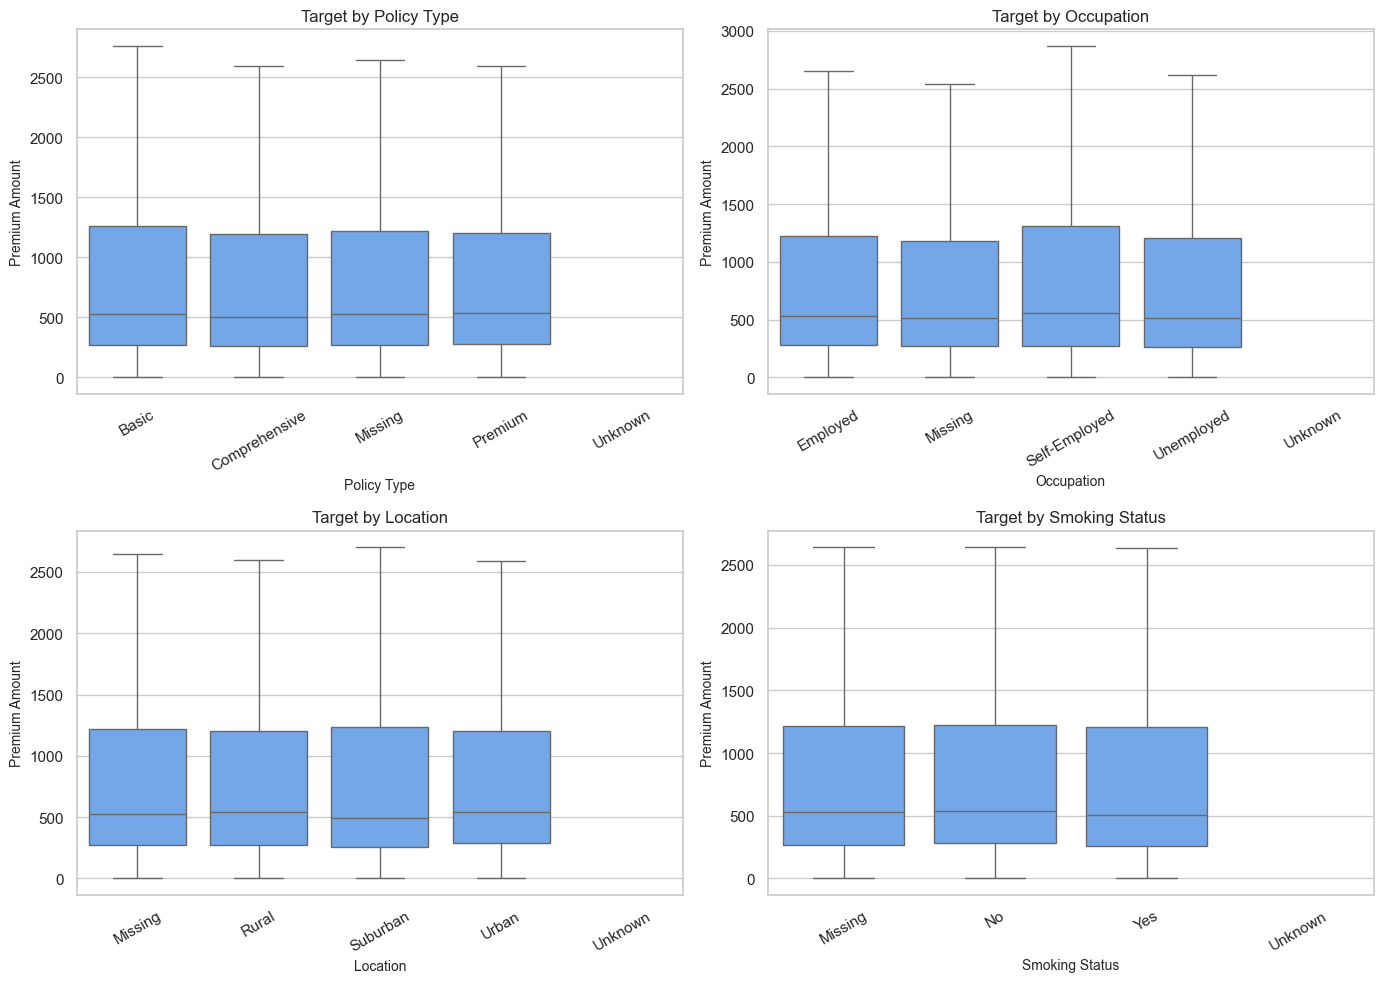

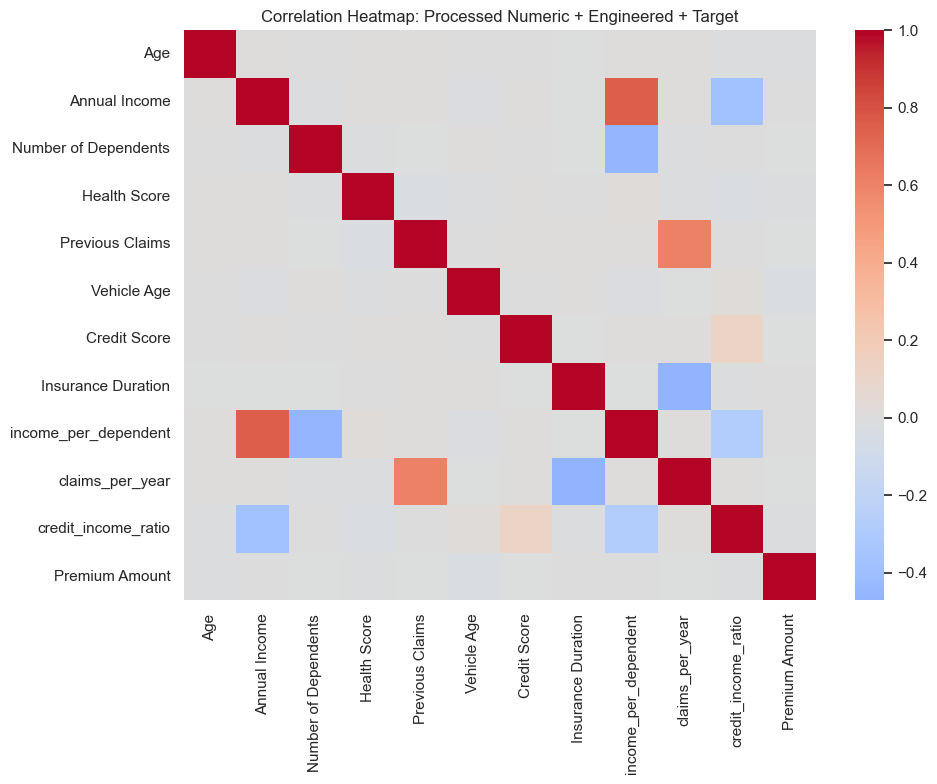

In [33]:
# Processed target relationships and correlation diagnostics
# Target by key processed categorical features
top_cat_for_target = ["Policy Type", "Occupation", "Location", "Smoking Status"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for idx, col in enumerate(top_cat_for_target):
    sns.boxplot(
        data=eda_processed_train_df,
        x=col,
        y=TARGET_COL,
        ax=axes[idx],
        showfliers=False,
        color="#60a5fa",
    )
    axes[idx].set_title(f"Target by {col}")
    axes[idx].tick_params(axis="x", rotation=30)
plt.tight_layout()
save_plot(fig, "target_by_category_boxplots")
plt.show()

corr_cols = [
    "Age",
    "Annual Income",
    "Number of Dependents",
    "Health Score",
    "Previous Claims",
    "Vehicle Age",
    "Credit Score",
    "Insurance Duration",
    "income_per_dependent",
    "claims_per_year",
    "credit_income_ratio",
    TARGET_COL,
]
corr_matrix = eda_processed_train_df[corr_cols].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap: Processed Numeric + Engineered + Target")
plt.tight_layout()
save_plot(fig, "correlation_heatmap")
plt.show()


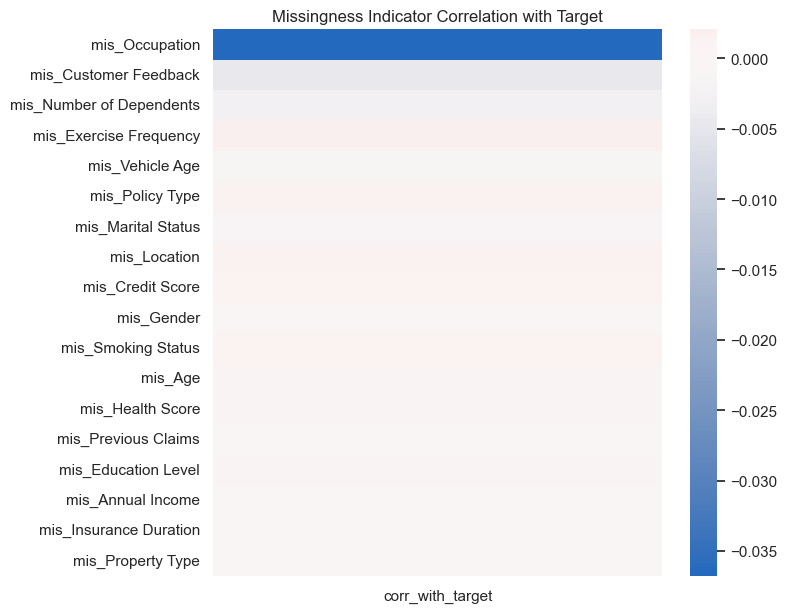

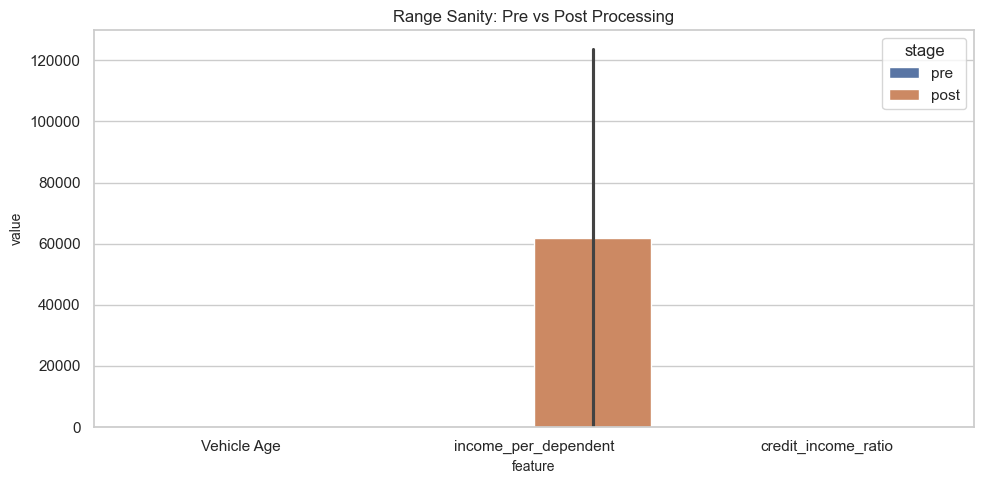

In [34]:
# Processed leakage/sanity diagnostics
mis_cols = sorted([c for c in eda_processed_train_df.columns if c.startswith("mis_")])
if mis_cols:
    mis_corr = eda_processed_train_df[mis_cols + [TARGET_COL]].corr(numeric_only=True)
    target_corr = (
        mis_corr[[TARGET_COL]]
        .drop(index=[TARGET_COL], errors="ignore")
        .rename(columns={TARGET_COL: "corr_with_target"})
        .sort_values("corr_with_target", key=lambda s: s.abs(), ascending=False)
    )

    fig, ax = plt.subplots(figsize=(8, max(4, len(target_corr) * 0.35)))
    sns.heatmap(target_corr, annot=False, cmap="vlag", center=0, ax=ax)
    ax.set_title("Missingness Indicator Correlation with Target")
    plt.tight_layout()
    save_plot(fig, "missing_indicator_target_corr")
    plt.show()

pre_post_range_rows = []
for col in ["Vehicle Age", "income_per_dependent", "credit_income_ratio"]:
    pre_col = train_df[col] if col in train_df.columns else pd.Series(dtype=float)
    post_col = eda_processed_train_df[col]
    pre_post_range_rows.extend(
        [
            {
                "feature": col,
                "stage": "pre",
                "metric": "min",
                "value": float(pre_col.min()) if len(pre_col) else np.nan,
            },
            {
                "feature": col,
                "stage": "pre",
                "metric": "max",
                "value": float(pre_col.max()) if len(pre_col) else np.nan,
            },
            {
                "feature": col,
                "stage": "post",
                "metric": "min",
                "value": float(post_col.min()),
            },
            {
                "feature": col,
                "stage": "post",
                "metric": "max",
                "value": float(post_col.max()),
            },
        ]
    )

range_df = pd.DataFrame(pre_post_range_rows)
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=range_df, x="feature", y="value", hue="stage", ax=ax)
ax.set_title("Range Sanity: Pre vs Post Processing")
plt.tight_layout()
save_plot(fig, "pre_post_range_sanity")
plt.show()


In [35]:
# Targeted missingness EDA for highest-missing categorical features
TARGET_MISSING_COLS = ["Occupation", "Marital Status", "Location"]
GROUP_KEYS = ["Policy Type", "age_band", "Education Level"]

missing_group_frames = []
for feature in TARGET_MISSING_COLS:
    grp = (
        eda_processed_train_df.groupby(GROUP_KEYS, observed=True)
        .agg(
            rows=(feature, "size"),
            missing_rate_pct=(
                feature,
                lambda s: float((s.astype("string") == "Missing").mean() * 100),
            ),
            target_mean=(TARGET_COL, "mean"),
            target_median=(TARGET_COL, "median"),
        )
        .reset_index()
        .sort_values(["missing_rate_pct", "rows"], ascending=[False, False])
    )
    grp["feature"] = feature
    missing_group_frames.append(grp.head(30))

targeted_missingness_by_group_df = pd.concat(missing_group_frames, ignore_index=True)
save_df(targeted_missingness_by_group_df, "targeted_missingness_by_group")

display(targeted_missingness_by_group_df.head(20))

missing_signal_rows = []
target_by_level_frames = []
for feature in TARGET_MISSING_COLS:
    level_stats = (
        eda_processed_train_df.groupby(feature, observed=True)[TARGET_COL]
        .agg(["count", "mean", "median"])
        .reset_index()
        .sort_values("count", ascending=False)
    )
    level_stats["feature"] = feature
    target_by_level_frames.append(level_stats)

    is_missing = eda_processed_train_df[feature].astype("string") == "Missing"
    missing_values = eda_processed_train_df.loc[is_missing, TARGET_COL]
    observed_values = eda_processed_train_df.loc[~is_missing, TARGET_COL]

    missing_signal_rows.append(
        {
            "feature": feature,
            "missing_share_pct": float(is_missing.mean() * 100),
            "target_mean_missing": float(missing_values.mean())
            if len(missing_values)
            else np.nan,
            "target_mean_non_missing": float(observed_values.mean())
            if len(observed_values)
            else np.nan,
            "target_median_missing": float(missing_values.median())
            if len(missing_values)
            else np.nan,
            "target_median_non_missing": float(observed_values.median())
            if len(observed_values)
            else np.nan,
            "abs_mean_gap": float(abs(missing_values.mean() - observed_values.mean()))
            if len(missing_values) and len(observed_values)
            else np.nan,
            "missing_predictive_flag": int(
                len(missing_values) > 0
                and len(observed_values) > 0
                and abs(missing_values.mean() - observed_values.mean()) > 0
            ),
        }
    )

target_by_level_df = pd.concat(target_by_level_frames, ignore_index=True)
missing_signal_df = pd.DataFrame(missing_signal_rows)
save_df(target_by_level_df, "target_by_missing_levels")
save_df(missing_signal_df, "missing_signal_summary")

display(missing_signal_df)


,Policy Type,age_band,Education Level,rows,missing_rate_pct,target_mean,target_median,feature
0,Premium,"(65.0, inf]",Bachelor's,4,100.000000,886.955000,893.205,Occupation
1,Missing,"(65.0, inf]",Missing,1,100.000000,654.530000,654.530,Occupation
2,Comprehensive,"(65.0, inf]",Master's,5,80.000000,963.524000,393.340,Occupation
3,Premium,"(65.0, inf]",Master's,5,60.000000,664.278000,297.430,Occupation
4,Premium,"(65.0, inf]",Missing,5,60.000000,718.204000,494.630,Occupation
5,Comprehensive,"(55.0, 65.0]",Bachelor's,7465,49.109176,835.889326,542.320,Occupation
6,Comprehensive,"(45.0, 55.0]",Bachelor's,12398,48.782062,846.546831,532.955,Occupation
7,Missing,"(55.0, 65.0]",Bachelor's,3121,46.427427,870.417267,560.110,Occupation
8,Premium,"(45.0, 55.0]",Bachelor's,18347,46.399956,868.269194,547.370,Occupation
9,Premium,"(55.0, 65.0]",Bachelor's,10530,46.115859,871.330219,563.000,Occupation


,feature,missing_share_pct,target_mean_missing,target_mean_non_missing,target_median_missing,target_median_non_missing,abs_mean_gap,missing_predictive_flag
0,Occupation,39.920192,809.333515,871.099081,510.35,533.28,61.765566,1
1,Marital Status,25.740962,844.464772,847.127581,526.92,523.34,2.662808,1
2,Location,23.717885,848.478555,845.808982,524.35,524.26,2.669573,1


In [36]:
# Preprocessing ablation with fixed CV split (A/B/C)
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

ABLAT_COLS = ["Occupation", "Marital Status", "Location"]
A_LABELS = {
    "A": "hierarchical_then_raw_missing_override",
    "B": "preserve_missing_labels_no_hierarchical",
    "C": "hierarchical_without_raw_missing_override",
}


def _normalize_cat(series: pd.Series) -> pd.Series:
    s = series.astype("string")
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()
    low = s.str.lower()
    return s.mask(low.isin(MISSING_TOKENS), pd.NA)


def _hier_fill(
    train_s: pd.Series,
    test_s: pd.Series,
    train_keys: pd.DataFrame,
    test_keys: pd.DataFrame,
):
    observed = pd.DataFrame(
        {
            "policy": train_keys["policy"],
            "age_band_tmp": train_keys["age_band_tmp"],
            "edu": train_keys["edu"],
            "val": train_s,
        }
    )
    observed = observed[observed["val"].notna()]

    map_a = {}
    for key, g in observed.groupby(["policy", "age_band_tmp", "edu"], dropna=False):
        m = g["val"].mode(dropna=True)
        if len(m):
            map_a[key] = m.iloc[0]

    map_b = {}
    for key, g in observed.groupby(["policy", "age_band_tmp"], dropna=False):
        m = g["val"].mode(dropna=True)
        if len(m):
            map_b[key] = m.iloc[0]

    global_mode = train_s.dropna().mode(dropna=True)
    global_mode = global_mode.iloc[0] if len(global_mode) else "Missing"

    def apply_fill(s: pd.Series, keys: pd.DataFrame) -> pd.Series:
        out = s.copy()
        for ridx in out[out.isna()].index:
            k3 = (
                keys.at[ridx, "policy"],
                keys.at[ridx, "age_band_tmp"],
                keys.at[ridx, "edu"],
            )
            k2 = (keys.at[ridx, "policy"], keys.at[ridx, "age_band_tmp"])
            if k3 in map_a:
                out.at[ridx] = map_a[k3]
            elif k2 in map_b:
                out.at[ridx] = map_b[k2]
            else:
                out.at[ridx] = global_mode
        return out

    return apply_fill(train_s, train_keys), apply_fill(test_s, test_keys)


def preprocess_for_ablation(
    train_raw: pd.DataFrame, test_raw: pd.DataFrame, variant: str
):
    tr = train_raw.copy(deep=True)
    te = test_raw.copy(deep=True)

    raw_missing_mask = {}
    for col in CAT_COLS:
        tr[col] = _normalize_cat(tr[col])
        te[col] = _normalize_cat(te[col])
        raw_missing_mask[col] = {
            "train": tr[col].isna().copy(),
            "test": te[col].isna().copy(),
        }

    for col in NUM_COLS + [TARGET_COL]:
        if col in tr.columns:
            tr[col] = pd.to_numeric(tr[col], errors="coerce")
    for col in NUM_COLS:
        if col in te.columns:
            te[col] = pd.to_numeric(te[col], errors="coerce")

    for col, (min_val, max_val) in DOMAIN_RULES.items():
        for df in (tr, te):
            bad = pd.Series(False, index=df.index)
            if min_val is not None:
                bad = bad | (df[col] < min_val)
            if max_val is not None:
                bad = bad | (df[col] > max_val)
            df.loc[bad, col] = np.nan

    for col in NUM_COLS + CAT_COLS:
        ind_col = f"mis_{col}"
        tr[ind_col] = tr[col].isna().astype("int8")
        te[ind_col] = te[col].isna().astype("int8")

    medians = tr[NUM_COLS].median(numeric_only=True)
    tr[NUM_COLS] = tr[NUM_COLS].fillna(medians)
    te[NUM_COLS] = te[NUM_COLS].fillna(medians)

    age_bins_tmp = [0, 25, 35, 45, 55, 65, np.inf]
    tr_age = pd.cut(tr["Age"], bins=age_bins_tmp, include_lowest=True)
    te_age = pd.cut(te["Age"], bins=age_bins_tmp, include_lowest=True)
    keys_tr = pd.DataFrame(
        {
            "policy": tr["Policy Type"].astype("string"),
            "age_band_tmp": tr_age.astype("string"),
            "edu": tr["Education Level"].astype("string"),
        }
    )
    keys_te = pd.DataFrame(
        {
            "policy": te["Policy Type"].astype("string"),
            "age_band_tmp": te_age.astype("string"),
            "edu": te["Education Level"].astype("string"),
        }
    )

    if variant in {"A", "C"}:
        for col in ABLAT_COLS:
            tr[col], te[col] = _hier_fill(
                tr[col].astype("string"), te[col].astype("string"), keys_tr, keys_te
            )

    for col in CAT_COLS:
        tr[col] = tr[col].astype("string").fillna("Missing")
        te[col] = te[col].astype("string").fillna("Missing")

    for col in CAT_COLS:
        canonical = CANONICAL_LEVELS[col]
        lookup = {v.lower(): v for v in canonical}
        lookup["master’s"] = "Master's"
        lookup["missing"] = "Missing"

        mapped_tr = (
            tr[col]
            .astype("string")
            .str.strip()
            .str.lower()
            .map(lookup)
            .fillna("Unknown")
        )
        mapped_te = (
            te[col]
            .astype("string")
            .str.strip()
            .str.lower()
            .map(lookup)
            .fillna("Unknown")
        )

        if variant in {"A", "B"}:
            mapped_tr = mapped_tr.mask(raw_missing_mask[col]["train"], "Missing")
            mapped_te = mapped_te.mask(raw_missing_mask[col]["test"], "Missing")

        tr[col] = mapped_tr
        te[col] = mapped_te

        vocab = sorted(tr[col].dropna().unique().tolist())
        for fixed in ["Missing", "Unknown"]:
            if fixed not in vocab:
                vocab.append(fixed)

        te.loc[~te[col].isin(vocab), col] = "Unknown"
        dtype = CategoricalDtype(categories=vocab, ordered=False)
        tr[col] = tr[col].astype(dtype)
        te[col] = te[col].astype(dtype)

    for col in LOG_COLS:
        tr[f"log1p_{col}"] = np.log1p(np.clip(tr[col], a_min=0, a_max=None))
        te[f"log1p_{col}"] = np.log1p(np.clip(te[col], a_min=0, a_max=None))

    for col in WINSOR_COLS:
        ql = float(tr[col].quantile(0.005))
        qh = float(tr[col].quantile(0.995))
        tr[f"clip_{col}"] = tr[col].clip(lower=ql, upper=qh)
        te[f"clip_{col}"] = te[col].clip(lower=ql, upper=qh)

    tr["is_zero_income"] = (tr["Annual Income"] <= 0).astype("int8")
    te["is_zero_income"] = (te["Annual Income"] <= 0).astype("int8")
    tr["income_per_dependent"] = tr["Annual Income"] / (tr["Number of Dependents"] + 1)
    te["income_per_dependent"] = te["Annual Income"] / (te["Number of Dependents"] + 1)

    tr_claim_denom = tr["Insurance Duration"].replace(0, np.nan)
    te_claim_denom = te["Insurance Duration"].replace(0, np.nan)
    tr["claims_per_year"] = (tr["Previous Claims"] / tr_claim_denom).fillna(0.0)
    te["claims_per_year"] = (te["Previous Claims"] / te_claim_denom).fillna(0.0)

    tr_income_floor = tr["Annual Income"].clip(lower=1000.0)
    te_income_floor = te["Annual Income"].clip(lower=1000.0)
    tr["credit_income_ratio"] = tr["Credit Score"] / tr_income_floor
    te["credit_income_ratio"] = te["Credit Score"] / te_income_floor

    for col in ["income_per_dependent", "credit_income_ratio"]:
        ql = float(tr[col].quantile(0.005))
        qh = float(tr[col].quantile(0.995))
        tr[col] = tr[col].clip(lower=ql, upper=qh)
        te[col] = te[col].clip(lower=ql, upper=qh)

    bin_specs = {
        "age_band": ("Age", [0, 25, 35, 45, 55, 65, np.inf]),
        "income_band": ("Annual Income", [0, 10000, 30000, 60000, 100000, np.inf]),
        "credit_band": ("Credit Score", [0, 400, 550, 700, 800, np.inf]),
        "vehicle_age_band": ("Vehicle Age", [0, 3, 7, 12, 20, np.inf]),
    }
    for band_col, (base_col, edges) in bin_specs.items():
        tr[band_col] = pd.cut(tr[base_col], bins=edges, include_lowest=True)
        te[band_col] = pd.cut(te[base_col], bins=edges, include_lowest=True)

    base_cols = [c for c in (NUM_COLS + CAT_COLS) if c in tr.columns]
    indicator_cols = sorted([c for c in tr.columns if c.startswith("mis_")])
    log_cols = sorted([c for c in tr.columns if c.startswith("log1p_")])
    clip_cols = sorted([c for c in tr.columns if c.startswith("clip_")])
    derived_cols = [
        "is_zero_income",
        "income_per_dependent",
        "claims_per_year",
        "credit_income_ratio",
    ]
    bin_cols = ["age_band", "income_band", "credit_band", "vehicle_age_band"]
    ordered = [
        *base_cols,
        *indicator_cols,
        *log_cols,
        *clip_cols,
        *derived_cols,
        *bin_cols,
    ]
    ordered = [c for c in ordered if c in tr.columns]

    tr_out = tr[[*ordered, TARGET_COL]].copy()
    te_out = te[ordered].copy()
    return tr_out, te_out


ablation_rows = []
cv = KFold(n_splits=5, shuffle=True, random_state=232)

for variant in ["A", "B", "C"]:
    tr_variant, te_variant = preprocess_for_ablation(train_raw_df, test_raw_df, variant)

    assert tr_variant.drop(columns=[TARGET_COL]).shape[1] == te_variant.shape[1]
    assert tr_variant.isna().sum().sum() == 0
    assert te_variant.isna().sum().sum() == 0

    X = tr_variant.drop(columns=[TARGET_COL]).copy()
    y = tr_variant[TARGET_COL].to_numpy()

    cat_cols_cv = [c for c in X.columns if str(X[c].dtype) == "category"]
    num_cols_cv = [c for c in X.columns if c not in cat_cols_cv]

    for c in cat_cols_cv:
        X[c] = X[c].astype("string")

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("ohe", OneHotEncoder(handle_unknown="ignore")),
                    ]
                ),
                cat_cols_cv,
            ),
            (
                "num",
                Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]),
                num_cols_cv,
            ),
        ],
        remainder="drop",
    )

    model = Ridge(alpha=1.0)
    pipe = Pipeline(steps=[("prep", preprocessor), ("model", model)])

    mae_scores = -cross_val_score(
        pipe,
        X,
        y,
        cv=cv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
    )

    ablation_rows.append(
        {
            "variant": variant,
            "variant_label": A_LABELS[variant],
            "cv_mae_mean": float(mae_scores.mean()),
            "cv_mae_std": float(mae_scores.std()),
            "n_features": int(X.shape[1]),
            "train_rows": int(len(X)),
        }
    )

preprocessing_ablation_df = pd.DataFrame(ablation_rows).sort_values(
    "cv_mae_mean", ascending=True
)
best_variant = preprocessing_ablation_df.iloc[0]["variant"]
best_variant_label = preprocessing_ablation_df.iloc[0]["variant_label"]

save_df(preprocessing_ablation_df, "preprocessing_ablation_cv")
display(preprocessing_ablation_df)
print(
    f"Selected preprocessing variant by CV MAE: {best_variant} ({best_variant_label})"
)


,variant,variant_label,cv_mae_mean,cv_mae_std,n_features,train_rows
0,A,hierarchical_then_raw_missing_override,639.767007,0.641706,55,520000
1,B,preserve_missing_labels_no_hierarchical,639.767007,0.641706,55,520000
2,C,hierarchical_without_raw_missing_override,639.831896,0.638426,55,520000


Selected preprocessing variant by CV MAE: A (hierarchical_then_raw_missing_override)


In [37]:
# Actionable EDA issue report
issue_rows = []

preserve_missing_features = set(["Occupation", "Marital Status", "Location"])

# Missingness issues
for _, row in missing_compare_df.iterrows():
    train_miss = float(row["train_missing_pct"])
    test_miss = float(row["test_missing_pct"])
    miss_gap = abs(train_miss - test_miss)

    feature = row["feature"]
    if train_miss >= 35:
        if feature in preserve_missing_features:
            issue_rows.append(
                {
                    "issue_type": "high_missingness_signal_preserved",
                    "feature": feature,
                    "evidence_metric": "train_missing_pct",
                    "value": train_miss,
                    "severity": "low",
                    "suggested_fix": "keep Missing label + indicator; validate predictive lift through CV ablation",
                }
            )
        else:
            issue_rows.append(
                {
                    "issue_type": "high_missingness",
                    "feature": feature,
                    "evidence_metric": "train_missing_pct",
                    "value": train_miss,
                    "severity": "high",
                    "suggested_fix": "consider stronger imputation strategy and monitor Missing/Unknown split impact",
                }
            )
    if miss_gap >= 3:
        issue_rows.append(
            {
                "issue_type": "missingness_drift",
                "feature": feature,
                "evidence_metric": "abs(train-test)_missing_pct",
                "value": miss_gap,
                "severity": "medium",
                "suggested_fix": "align preprocessing assumptions and check distribution shift",
            }
        )

# Outlier issues
for _, row in outlier_df.iterrows():
    if float(row["iqr_outlier_pct"]) >= 5:
        issue_rows.append(
            {
                "issue_type": "high_outlier_rate",
                "feature": row["feature"],
                "evidence_metric": "iqr_outlier_pct",
                "value": float(row["iqr_outlier_pct"]),
                "severity": "medium",
                "suggested_fix": "review clipping, transforms, or robust scaling for this feature",
            }
        )

# Label-share diagnostics (contextualized for preserved-missing strategy)
for col in CAT_COLS:
    train_missing_pct = float(
        (eda_processed_train_df[col].astype("string") == "Missing").mean() * 100
    )
    train_unknown_pct = float(
        (eda_processed_train_df[col].astype("string") == "Unknown").mean() * 100
    )

    if train_missing_pct >= 20:
        issue_rows.append(
            {
                "issue_type": (
                    "high_missing_label_share_expected"
                    if col in preserve_missing_features
                    else "high_missing_label_share"
                ),
                "feature": col,
                "evidence_metric": "train_missing_label_pct",
                "value": train_missing_pct,
                "severity": "low" if col in preserve_missing_features else "high",
                "suggested_fix": (
                    "expected under preserve-missing strategy; verify lift with CV and keep indicators"
                    if col in preserve_missing_features
                    else "improve group-wise fill quality for this feature before final modeling"
                ),
            }
        )

    if train_unknown_pct >= 5:
        issue_rows.append(
            {
                "issue_type": "high_unknown_label_share",
                "feature": col,
                "evidence_metric": "train_unknown_label_pct",
                "value": train_unknown_pct,
                "severity": "medium",
                "suggested_fix": "expand canonical mapping and inspect unseen/dirty category values",
            }
        )

# Category drift issues
for _, row in cat_drift_df.iterrows():
    if int(row.get("drift_flag_high", 0)) == 1:
        issue_rows.append(
            {
                "issue_type": "categorical_drift_high",
                "feature": row["feature"],
                "evidence_metric": "max_abs_category_share_delta_pct",
                "value": float(row["max_abs_category_share_delta_pct"]),
                "severity": "medium",
                "suggested_fix": "check train/test generation differences and category calibration",
            }
        )

# Numeric imputation warning
if numeric_impute_choice.get("method") == "iterative" and bool(
    numeric_imputation_instability
):
    issue_rows.append(
        {
            "issue_type": "numeric_imputation_warning",
            "feature": "NUM_COLS",
            "evidence_metric": "iterative_instability",
            "value": 1.0,
            "severity": "medium",
            "suggested_fix": f"fallback to median or tune iterative settings ({numeric_imputation_warning_reason})",
        }
    )

# CV ablation decision note (only when ablation actually ran)
if "preprocessing_ablation_df" in globals() and len(preprocessing_ablation_df):
    valid_ablation_df = preprocessing_ablation_df[
        preprocessing_ablation_df["variant"].astype("string") != "-"
    ].copy()
    valid_ablation_df = valid_ablation_df[valid_ablation_df["cv_mae_mean"].notna()]

    if len(valid_ablation_df):
        best_row = valid_ablation_df.sort_values("cv_mae_mean", ascending=True).iloc[0]
        issue_rows.append(
            {
                "issue_type": "preprocessing_cv_winner",
                "feature": "pipeline",
                "evidence_metric": "cv_mae_mean",
                "value": float(best_row["cv_mae_mean"]),
                "severity": "low",
                "suggested_fix": f"lock variant {best_row['variant']} ({best_row['variant_label']}) for modeling notebook",
            }
        )

eda_issue_report_df = pd.DataFrame(
    issue_rows,
    columns=[
        "issue_type",
        "feature",
        "evidence_metric",
        "value",
        "severity",
        "suggested_fix",
    ],
)

if eda_issue_report_df.empty:
    eda_issue_report_df = pd.DataFrame(
        [
            {
                "issue_type": "no_major_issue_detected",
                "feature": "-",
                "evidence_metric": "-",
                "value": 0.0,
                "severity": "low",
                "suggested_fix": "continue with current preprocessing and monitor after each new feature",
            }
        ]
    )

severity_order = pd.CategoricalDtype(categories=["high", "medium", "low"], ordered=True)
eda_issue_report_df["severity"] = eda_issue_report_df["severity"].astype(severity_order)
eda_issue_report_df = eda_issue_report_df.sort_values(
    ["severity", "value"], ascending=[True, False]
).reset_index(drop=True)

save_df(eda_issue_report_df, "eda_issue_report")

display(eda_issue_report_df)
print("eda_issue_report_df rows:", len(eda_issue_report_df))


,issue_type,feature,evidence_metric,value,severity,suggested_fix
0,preprocessing_cv_winner,pipeline,cv_mae_mean,639.767007,low,lock variant A (hierarchical_then_raw_missing_...
1,high_missingness_signal_preserved,Occupation,train_missing_pct,39.920192,low,keep Missing label + indicator; validate predi...
2,high_missing_label_share_expected,Occupation,train_missing_label_pct,39.920192,low,expected under preserve-missing strategy; veri...
3,high_missing_label_share_expected,Marital Status,train_missing_label_pct,25.740962,low,expected under preserve-missing strategy; veri...
4,high_missing_label_share_expected,Location,train_missing_label_pct,23.717885,low,expected under preserve-missing strategy; veri...


eda_issue_report_df rows: 5


In [38]:
# Outputs index (generated artifacts)
output_files = sorted(OUTPUT_DIR.glob("*"))
outputs_index_df = pd.DataFrame(
    [
        {
            "file_name": p.name,
            "size_kb": round(p.stat().st_size / 1024, 2),
            "modified_at": pd.to_datetime(p.stat().st_mtime, unit="s"),
        }
        for p in output_files
    ]
)

display(outputs_index_df)
print("Total output artifacts:", len(outputs_index_df))


,file_name,size_kb,modified_at
0,eda_issue_report_ins232-eda.csv,0.87,2026-03-14 05:57:08.825112343
1,ins232-eda_boxplot_skew_features.png,49.67,2026-03-14 05:55:25.604441881
2,ins232-eda_categorical_drift_max_abs_delta.png,72.16,2026-03-14 05:55:40.629076958
3,ins232-eda_category_counts_grid.png,314.90,2026-03-14 05:55:39.556309462
4,ins232-eda_correlation_heatmap.png,94.15,2026-03-14 05:55:42.338086605
...,...,...,...
29,ins232-eda_unknown_rate_by_feature.png,74.11,2026-03-14 05:55:40.119219303
30,missing_signal_summary_ins232-eda.csv,0.44,2026-03-14 05:55:43.299304247
31,preprocessing_ablation_cv_ins232-eda.csv,0.33,2026-03-14 05:57:08.374631166
32,target_by_missing_levels_ins232-eda.csv,0.69,2026-03-14 05:55:43.298536062


Total output artifacts: 34
